# CHƯƠNG 9: CHUỖI THỜI GIAN ĐA BIẾN (VAR/VECM) TRONG KINH TẾ TÀI CHÍNH

## 9.1. Tình huống dẫn dắt: Phân tích cú sốc vĩ mô

Vào đầu năm 2022, Cục Dự trữ Liên bang Mỹ (Fed) thực hiện chu kỳ tăng lãi suất tích cực nhất trong vòng bốn thập kỷ, đẩy lãi suất quỹ liên bang từ gần 0% lên 5.25-5.50% chỉ trong vòng 18 tháng. Trong cùng giai đoạn đó, đồng USD tăng mạnh so với hầu hết các đồng tiền trên thế giới — đồng Việt Nam mất giá khoảng 9% so với USD trong năm 2022 — trong khi VN-Index giảm từ đỉnh lịch sử 1.536 điểm (tháng 4/2022) xuống còn 873 điểm (tháng 11/2022), tương đương mức giảm 43% chỉ trong 7 tháng.

Đứng trước làn sóng biến động đồng thời của ba biến số vĩ mô — lãi suất, tỷ giá, và chỉ số chứng khoán — nhóm phân tích định lượng tại một quỹ đầu tư lớn phải giải quyết một bài toán phức tạp và cấp thiết: "Khi Fed tăng lãi suất thêm 25 điểm cơ bản, hiệu ứng truyền dẫn qua tỷ giá USD/VND và lãi suất trong nước sẽ làm VN-Index phản ứng như thế nào trong 12 tháng tới? Tác động đỉnh điểm sẽ xảy ra ở tháng thứ mấy và sẽ triệt tiêu sau bao lâu?"

Bài toán này không thể giải được bằng bất kỳ công cụ nào đã học trong các chương trước. Hồi quy tuyến tính OLS (Chương 6) giả định các quan sát độc lập với nhau — điều hoàn toàn sai với dữ liệu kinh tế theo thời gian vì giá cổ phiếu hôm nay phụ thuộc mạnh vào giá hôm qua. Phân tích nhân tố EFA/CFA (Chương 4 và 8) thiết kế cho dữ liệu cắt ngang (cross-sectional), không có khả năng mô hình hóa động lực học theo thời gian. SEM (Chương 8) có thể xử lý cấu trúc nhân quả nhưng không có cơ chế nội sinh để xử lý độ trễ (lags) — tức là tác động của quá khứ lên hiện tại.

Đây chính xác là lý do ra đời của lớp mô hình chuỗi thời gian đa biến (multivariate time series models). Mô hình Vector Autoregression (VAR) và người anh em của nó là Vector Error Correction Model (VECM) được thiết kế đặc biệt để xử lý ba đặc trưng riêng biệt của dữ liệu kinh tế vĩ mô: (1) Tính nội sinh tự nhiên — mọi biến kinh tế vĩ mô đều vừa là nguyên nhân vừa là hệ quả của các biến khác, không có ranh giới rõ ràng giữa biến độc lập và biến phụ thuộc; (2) Động lực học theo thời gian — tác động của một cú sốc không xảy ra tức thời mà lan truyền và suy giảm dần qua nhiều kỳ thời gian; (3) Cân bằng dài hạn — trong khi ngắn hạn các biến kinh tế có thể phân kỳ đáng kể, dài hạn chúng thường bị ràng buộc bởi các mối quan hệ kinh tế cơ bản (fundamental economic relationships).

Chương này xây dựng nền tảng lý thuyết và thực hành cho phân tích chuỗi thời gian đa biến, từ điều kiện tiên quyết về Tính dừng (Stationarity) và nguy cơ Hồi quy giả mạo (Spurious Regression), qua mô hình VAR cơ bản, đến mô hình VECM nâng cao tích hợp cả ngắn hạn lẫn dài hạn. Cuối chương, chúng ta sẽ sử dụng hai công cụ phân tích chính sách cực kỳ mạnh mẽ là Hàm phản ứng xung (Impulse Response Function - IRF) và Phân rã phương sai (Variance Decomposition - FEVD) để trả lời trực tiếp câu hỏi chiến lược của nhóm phân tích quỹ đầu tư.

Toàn bộ phần thực hành được thực hiện bằng Python với thư viện `statsmodels.tsa`, sử dụng bộ dữ liệu `macro_finance_timeseries.csv` chứa chuỗi số liệu tháng về lãi suất liên ngân hàng VNIBOR, tỷ giá USD/VND và chỉ số VN-Index trong giai đoạn 2015-2023.

Để hiểu rõ hơn về tính chất đặc thù của dữ liệu chuỗi thời gian kinh tế so với dữ liệu cắt ngang đã học trong các chương trước, hãy so sánh hai bài toán phân tích sau. Trong bài toán cắt ngang (cross-sectional), khi nghiên cứu mối quan hệ giữa thu nhập và chi tiêu của 1.000 hộ gia đình trong cùng một thời điểm, mỗi hộ là một quan sát độc lập — thu nhập của hộ thứ 500 không ảnh hưởng gì đến hộ thứ 501. Trong bài toán chuỗi thời gian, khi nghiên cứu lãi suất và VN-Index qua 108 tháng, mỗi quan sát KHÔNG độc lập với nhau — VN-Index tháng này phụ thuộc mạnh vào VN-Index tháng trước (momentum) và phản ứng với lãi suất của các tháng trước đó (lag effects). Sự vi phạm giả định độc lập này không chỉ làm cho OLS mất hiệu quả mà còn làm cho mọi kiểm định thống kê (t-test, F-test, R²) trở nên vô nghĩa về mặt xác suất.

Sự phức tạp còn tăng thêm khi xem xét đặc trưng tính nội sinh tự nhiên (natural endogeneity) của dữ liệu kinh tế vĩ mô. Trong mô hình hồi quy truyền thống, nhà nghiên cứu giả định có một chiều nhân quả rõ ràng: "lãi suất → VN-Index". Nhưng thực tế thị trường tài chính phức tạp hơn nhiều: lãi suất tăng làm VN-Index giảm (kênh chiết khấu — higher discount rate giảm present value của dòng tiền tương lai), nhưng đồng thời khi VN-Index giảm mạnh (tín hiệu kinh tế xấu), NHNN có thể phản ứng bằng cách hạ lãi suất để kích thích (kênh phản ứng chính sách). Quan hệ nhân quả chạy theo cả hai chiều đồng thời — đây chính xác là vấn đề mà mô hình VAR được thiết kế để xử lý bằng cách đặt tất cả biến vào thế đối xứng.

Một đặc trưng quan trọng khác là cấu trúc phụ thuộc theo thời gian (temporal dependence structure). Giá cổ phiếu hôm nay bị ảnh hưởng bởi thông tin từ hôm qua (lag 1), nhưng cũng bởi thông tin từ một tháng trước (lag 30) và thậm chí một năm trước (lag 252 — hiệu ứng tháng 1, hiệu ứng cuối năm tài chính). Cấu trúc phụ thuộc này được đo lường bằng hàm tự tương quan (Autocorrelation Function — ACF) và hàm tự tương quan riêng phần (Partial Autocorrelation Function — PACF), là những công cụ chẩn đoán bắt buộc trước khi xây dựng bất kỳ mô hình chuỗi thời gian nào.

Từ góc nhìn lịch sử phát triển kinh tế lượng, mô hình VAR ra đời năm 1980 khi Christopher Sims — người sau này nhận Giải Nobel Kinh tế năm 2011 — công bố bài báo có tựa đề "Macroeconomics and Reality" trên tạp chí Econometrica. Sims chỉ trích mạnh mẽ các mô hình kinh tế lượng vĩ mô lớn thời đó (như mô hình Brookings Institution với hàng trăm phương trình) vì chúng áp đặt quá nhiều ràng buộc lý thuyết a priori để phân biệt biến ngoại sinh và nội sinh — một sự phân biệt mà ông cho là "không thể biện hộ được về mặt lý thuyết" (incredible identification restrictions). Thay vào đó, Sims đề xuất VAR như một framework atheoretical (không áp đặt lý thuyết) để mô tả động lực học nội sinh của các biến kinh tế vĩ mô và để phân tích phản ứng của chúng đối với các cú sốc chính sách.

Bối cảnh lịch sử này còn cho thấy một bài học quan trọng về tầm nhìn của kinh tế lượng hiện đại: các mô hình chuỗi thời gian đa biến không chỉ đơn thuần là công cụ thống kê mà còn là ngôn ngữ để đặt và kiểm định các giả thuyết kinh tế về cơ chế truyền dẫn chính sách. Khi NHNN Việt Nam muốn biết liệu chính sách thắt chặt tiền tệ có thực sự truyền dẫn sang lãi suất liên ngân hàng, tỷ giá và cuối cùng là thị trường chứng khoán trong bối cảnh Việt Nam hay không — đây không chỉ là câu hỏi học thuật mà là câu hỏi chính sách cấp bách. Mô hình VAR/VECM cung cấp framework định lượng để trả lời câu hỏi này với độ chính xác và tính minh bạch mà không một cách tiếp cận định tính nào có thể đạt được.

Chương này do đó không chỉ truyền đạt kỹ năng kỹ thuật mà còn trang bị cho người học một tư duy phân tích kinh tế định lượng đặc thù: tư duy về động lực học (dynamics), về trễ thời gian (lags), về quan hệ cân bằng dài hạn và cơ chế điều chỉnh ngắn hạn — những yếu tố mà kinh tế học vi mô và tĩnh (static economics) không thể nắm bắt được. Đây là bộ công cụ không thể thiếu trong hộp dụng cụ của bất kỳ nhà phân tích kinh tế định lượng hay nhà quản lý rủi ro tài chính chuyên nghiệp nào.

## 9.2. Tính dừng (Stationarity) và Mô hình Tự hồi quy Vector (VAR)

Khái niệm Tính dừng (Stationarity) là nền tảng bắt buộc phải nắm vững trước khi bước vào bất kỳ phân tích chuỗi thời gian nào. Một chuỗi thời gian $\{y_t\}$ được gọi là **dừng yếu (weakly stationary)** khi ba điều kiện sau được thỏa mãn đồng thời:

$$E(y_t) = \mu \quad \forall t \quad \text{(kỳ vọng không đổi theo thời gian)}$$

$$\text{Var}(y_t) = \sigma^2 < \infty \quad \forall t \quad \text{(phương sai hữu hạn và bất biến)}$$

$$\text{Cov}(y_t, y_{t-k}) = \gamma_k \quad \forall t \quad \text{(hiệp phương sai chỉ phụ thuộc vào độ trễ } k \text{, không phụ thuộc vào } t)$$

Điều kiện thứ ba đặc biệt quan trọng: nó đòi hỏi rằng mối quan hệ thống kê giữa $y_t$ và $y_{t-k}$ phải ổn định theo thời gian, bất kể $t$ là kỳ nào. Chuỗi thời gian tài chính thực tế (giá cổ phiếu, tỷ giá, lãi suất) hầu như không bao giờ thỏa mãn điều kiện này ở dạng gốc của chúng vì các chuỗi này thường có xu hướng (trend) tăng hoặc giảm theo thời gian, làm cho kỳ vọng và phương sai thay đổi liên tục.

### 9.2.1. Hồi quy giả mạo (Spurious Regression) — Mối nguy hiểm tiềm ẩn

Hậu quả nghiêm trọng nhất của việc áp dụng hồi quy OLS lên hai chuỗi không dừng (non-stationary) là hiện tượng **Hồi quy giả mạo (Spurious Regression)**, được Granger và Newbold mô tả đầu tiên năm 1974 và được Phillips chứng minh về mặt lý thuyết năm 1986. Để hiểu trực giác, hãy tưởng tượng hồi quy chuỗi dân số thế giới (tăng đều theo thời gian) lên chuỗi nhiệt độ Trái Đất (cũng tăng đều do biến đổi khí hậu). Mô hình OLS sẽ cho ra $R^2 > 0.9$ và p-value cực nhỏ, nhưng đây hoàn toàn là kết quả giả mạo — hai chuỗi không hề có quan hệ nhân quả, chúng chỉ cùng có xu hướng tăng theo thời gian.

Về mặt toán học, Phillips (1986) chứng minh rằng khi $y_t$ và $x_t$ là hai Random Walk độc lập ($y_t = y_{t-1} + \varepsilon_t^y$ và $x_t = x_{t-1} + \varepsilon_t^x$ với $\varepsilon_t^y, \varepsilon_t^x$ độc lập), thống kê $t$ trong hồi quy OLS $y_t = \alpha + \beta x_t + u_t$ không hội tụ về phân phối chuẩn tắc mà thay vào đó phân kỳ khi $T \to \infty$. Điều này có nghĩa là ngay cả khi không có mối quan hệ thực sự, xác suất từ chối giả thuyết $H_0: \beta = 0$ tiến về 1 khi cỡ mẫu tăng — mô hình luôn tìm thấy "ý nghĩa thống kê" dù thực tế không có.

### 9.2.2. Kiểm định nghiệm đơn vị (Unit Root Test) — ADF Test

Tiêu chuẩn phân biệt chuỗi dừng và không dừng được thực hiện thông qua nhóm kiểm định nghiệm đơn vị (unit root tests). Kiểm định Augmented Dickey-Fuller (ADF), phát triển bởi Dickey và Fuller (1979, 1981) và được Augmented bởi Said và Dickey (1984), là kiểm định phổ biến nhất trong thực tiễn.

Mô hình kiểm định ADF dạng đầy đủ (với hằng số và xu hướng thời gian):

$$\Delta y_t = \alpha + \beta t + \rho y_{t-1} + \sum_{j=1}^{p} \gamma_j \Delta y_{t-j} + \varepsilon_t$$

trong đó $\Delta y_t = y_t - y_{t-1}$ là sai phân bậc một, $\alpha$ là hằng số (drift), $\beta t$ là thành phần xu hướng xác định (deterministic trend), và $p$ là số độ trễ bổ sung để xử lý tự tương quan trong phần dư. Giả thuyết kiểm định là: $H_0: \rho = 0$ (chuỗi có nghiệm đơn vị — không dừng) so với $H_1: \rho < 0$ (chuỗi dừng). Thống kê kiểm định $\tau = \hat{\rho}/SE(\hat{\rho})$ không có phân phối chuẩn tắc mà tuân theo phân phối Dickey-Fuller đặc biệt với các giá trị tới hạn (critical values) được tính bằng mô phỏng Monte Carlo.

Một điểm tinh tế quan trọng: số độ trễ $p$ trong mô hình ADF phải được lựa chọn cẩn thận. Quá ít độ trễ làm phần dư còn tự tương quan, vi phạm giả định của kiểm định và dẫn đến sai lệch về phía bác bỏ $H_0$ quá nhiều (size distortion). Quá nhiều độ trễ làm giảm power của kiểm định. Tiêu chuẩn thông dụng nhất là chọn $p$ bằng cách tối thiểu hóa AIC hoặc BIC trên mô hình ADF với các giá trị $p$ khác nhau, thường trong khoảng $[0, \sqrt{T}]$.

### 9.2.3. Mô hình VAR(p) — Kiến trúc và Ý nghĩa

Sau khi đã xác nhận tính dừng (hoặc đã lấy sai phân để đạt dừng), chúng ta sẵn sàng xây dựng mô hình Vector Autoregression. Mô hình VAR được giới thiệu bởi Christopher Sims năm 1980 như một phản ứng trực tiếp trước sự phê phán của Sims đối với các mô hình kinh tế lượng vĩ mô truyền thống: "Các mô hình đó áp đặt quá nhiều ràng buộc lý thuyết a priori không có cơ sở thực nghiệm." Thay vào đó, VAR đối xử đối xứng với tất cả các biến — mọi biến đều là biến phụ thuộc, và tất cả đều được hồi quy lên giá trị trễ của toàn bộ hệ thống.

Mô hình VAR bậc $p$ — ký hiệu VAR(p) — cho hệ $K$ biến $\mathbf{y}_t = (y_{1t}, y_{2t}, \ldots, y_{Kt})^\prime$ được viết như sau:

$$\mathbf{y}_t = \boldsymbol{\nu} + \mathbf{A}_1 \mathbf{y}_{t-1} + \mathbf{A}_2 \mathbf{y}_{t-2} + \cdots + \mathbf{A}_p \mathbf{y}_{t-p} + \mathbf{u}_t$$

trong đó $\boldsymbol{\nu}$ là véc-tơ hằng số $(K \times 1)$, $\mathbf{A}_i$ là ma trận hệ số $(K \times K)$ tại độ trễ $i$, và $\mathbf{u}_t$ là véc-tơ nhiễu trắng (white noise) đa biến với $E(\mathbf{u}_t) = \mathbf{0}$ và $E(\mathbf{u}_t \mathbf{u}_t^\prime) = \boldsymbol{\Sigma}_u$. Mỗi phương trình trong hệ thống có thể được ước lượng độc lập bằng OLS và kết quả là **Best Linear Unbiased Estimators (BLUE)** khi phần dư đa biến không tự tương quan.

Trong ứng dụng ba biến ($K=3$): $y_{1t}$ = lãi suất VNIBOR, $y_{2t}$ = log(tỷ giá USD/VND), $y_{3t}$ = log(VN-Index), với VAR(2), mỗi phương trình sẽ ước lượng tác động của 2 kỳ trễ của cả 3 biến, tức là 6 hệ số plus hằng số = 7 tham số mỗi phương trình và $3 \times 7 = 21$ tham số toàn hệ thống. Tổng số quan sát cần thiết để ước lượng ổn định thường gấp ít nhất 10 lần số tham số, tức là cần ít nhất 210 quan sát — tương đương hơn 17 năm dữ liệu tháng.

### 9.2.4. Lựa chọn Độ trễ tối ưu cho VAR

Việc lựa chọn bậc $p$ phù hợp cho mô hình VAR là một quyết định quan trọng ảnh hưởng trực tiếp đến chất lượng dự báo và độ tin cậy của phân tích chính sách. Nếu $p$ quá nhỏ, mô hình sẽ bỏ sót các quan hệ động lực học quan trọng (underfitting, gây thiên lệch); nếu $p$ quá lớn, mô hình có quá nhiều tham số cần ước lượng và kết quả IRF sẽ không ổn định (overfitting, gây mất hiệu quả ước lượng).

Bốn tiêu chuẩn thông tin chính được sử dụng để lựa chọn $p$:

$$\text{AIC}(p) = \ln |\hat{\boldsymbol{\Sigma}}_u(p)| + \frac{2}{T} K^2 p$$

$$\text{BIC}(p) = \ln |\hat{\boldsymbol{\Sigma}}_u(p)| + \frac{\ln T}{T} K^2 p$$

$$\text{HQC}(p) = \ln |\hat{\boldsymbol{\Sigma}}_u(p)| + \frac{2 \ln \ln T}{T} K^2 p$$

$$\text{FPE}(p) = \left(\frac{T + K p + 1}{T - K p - 1}\right)^K |\hat{\boldsymbol{\Sigma}}_u(p)|$$

trong đó $|\hat{\boldsymbol{\Sigma}}_u(p)|$ là định thức của ma trận phương sai-hiệp phương sai phần dư ước lượng. BIC có số hạng phạt lớn hơn AIC (do $\ln T > 2$ khi $T > 7$), do đó BIC có xu hướng chọn mô hình đơn giản hơn (ít độ trễ hơn), đặc biệt phù hợp khi cỡ mẫu lớn. Trong thực tiễn, nếu các tiêu chuẩn không đồng thuận, nhà nghiên cứu thường ưu tiên BIC và sau đó kiểm tra chẩn đoán phần dư (Portmanteau test) để đảm bảo không còn tự tương quan.

### 9.2.5. Phân tích Tự tương quan và PACF — Công cụ Chẩn đoán Trước Mô hình hóa

Trước khi ước lượng bất kỳ mô hình chuỗi thời gian nào, nhà nghiên cứu cần phân tích cấu trúc phụ thuộc theo thời gian của từng chuỗi thông qua hàm tự tương quan. **Hàm tự tương quan (ACF)** đo lường tương quan giữa $y_t$ và $y_{t-k}$ tại mỗi độ trễ $k$:

$$\rho_k = \frac{\text{Cov}(y_t, y_{t-k})}{\text{Var}(y_t)} = \frac{\gamma_k}{\gamma_0}$$

Với chuỗi dừng, $\rho_k \to 0$ khi $k \to \infty$ (tự tương quan suy giảm dần về không). Với chuỗi không dừng (Random Walk), $\rho_k \approx 1$ cho các $k$ nhỏ và giảm rất chậm — đây là dấu hiệu trực quan quan trọng nhất để nhận biết chuỗi không dừng mà không cần chạy ADF test.

**Hàm tự tương quan riêng phần (PACF)** đo lường tương quan "thuần túy" giữa $y_t$ và $y_{t-k}$ sau khi đã loại bỏ ảnh hưởng gián tiếp của $y_{t-1}, y_{t-2}, \ldots, y_{t-k+1}$. Cụ thể, PACF tại lag $k$ là hệ số $\phi_{kk}$ trong mô hình hồi quy:

$$y_t = \phi_{k1} y_{t-1} + \phi_{k2} y_{t-2} + \cdots + \phi_{kk} y_{t-k} + \varepsilon_t$$

Kết hợp đọc ACF và PACF giúp nhận dạng đặc trưng động lực học của chuỗi: ACF giảm dần theo hàm mũ và PACF cắt đứt tại lag $p$ là dấu hiệu của quá trình AR(p); ACF cắt đứt tại lag $q$ và PACF giảm dần theo hàm mũ là dấu hiệu của quá trình MA(q); khi cả ACF lẫn PACF đều giảm dần không cắt đứt, đó là dấu hiệu của ARMA(p,q). Trong bối cảnh VAR, phân tích ACF và PACF của từng chuỗi thành phần giúp định hướng ban đầu cho việc lựa chọn bậc $p$ tối ưu.

### 9.2.6. Kiểm định chẩn đoán phần dư sau khi ước lượng VAR

Sau khi ước lượng mô hình VAR, nhà nghiên cứu phải thực hiện một loạt kiểm định chẩn đoán trên phần dư để đảm bảo mô hình được chỉ định đúng (well-specified). Nếu phần dư còn tự tương quan, điều đó chứng tỏ mô hình chưa nắm bắt hết động lực học của dữ liệu và cần tăng bậc $p$.

Kiểm định Portmanteau (Ljung-Box) kiểm tra giả thuyết $H_0$: không có tự tương quan trong phần dư lên đến lag $h$. Thống kê kiểm định:

$$Q(h) = T(T+2) \sum_{k=1}^{h} \frac{\hat{\rho}_k^2}{T-k}$$

có phân phối xấp xỉ $\chi^2$ với $h \cdot K^2 - K^2 p$ bậc tự do (đã điều chỉnh cho số tham số ước lượng). Kiểm định Jarque-Bera cho phần dư đa biến kiểm tra tính chuẩn của phần dư — không phải điều kiện bắt buộc nhưng sự vi phạm nghiêm trọng có thể ảnh hưởng đến khoảng tin cậy Bootstrap của IRF. Kiểm định tính ổn định của mô hình VAR yêu cầu tất cả eigenvalues của ma trận đồng hành (companion matrix) nằm trong vòng tròn đơn vị — điều kiện để chuỗi là covariance-stationary và đảm bảo IRF hội tụ về không.

### 9.2.7. Nhân quả Granger (Granger Causality)

Khái niệm **nhân quả Granger** do Clive Granger (Nobel Kinh tế 2003) đề xuất năm 1969 là một định nghĩa nhân quả thống kê đặc thù cho chuỗi thời gian, khác biệt cơ bản với nhân quả nhân quả triết học hay nhân quả cấu trúc (structural causality). Granger định nghĩa: biến $x$ "Granger-cause" biến $y$ nếu thông tin về quá khứ của $x$ giúp dự báo $y$ tốt hơn so với chỉ dùng thông tin quá khứ của chính $y$.

Trong mô hình VAR, kiểm định nhân quả Granger được thực hiện bằng kiểm định F (hoặc Chi-square) trên ràng buộc tuyến tính. Để kiểm định $H_0$: $x$ không Granger-cause $y$, kiểm tra xem tất cả hệ số $\mathbf{A}_i$ trong hàng $y$ và cột $x$ (với $i = 1, \ldots, p$) đồng thời bằng không:

$$H_0: a_{yx,1} = a_{yx,2} = \cdots = a_{yx,p} = 0$$

Thống kê kiểm định tuân theo phân phối $\chi^2(p)$ tiệm cận. Kết quả nhân quả Granger phụ thuộc vào độ trễ $p$ được chọn và bậc tích hợp của chuỗi — nếu các chuỗi chưa được xử lý đúng (ví dụ: đang là I(1) nhưng không lấy sai phân), kết quả Granger causality sẽ bị chệch.

Điều quan trọng phải nhấn mạnh với người học: **Nhân quả Granger ≠ Nhân quả Cấu trúc**. Kết quả "lãi suất Granger-causes VN-Index" chỉ có nghĩa rằng thông tin về lãi suất quá khứ có giá trị dự báo tăng thêm cho VN-Index tương lai trong khuôn khổ hệ thống biến được đưa vào mô hình. Nó không chứng minh rằng lãi suất là nguyên nhân kinh tế thực sự của biến động VN-Index. Mối quan hệ có thể đảo ngược hoàn toàn nếu có một biến thứ ba bị bỏ sót (omitted variable) đồng thời tác động lên cả hai. Chỉ có thiết kế thực nghiệm (experiment) hoặc phương pháp biến công cụ (instrumental variables) mới có thể cung cấp bằng chứng nhân quả cấu trúc đáng tin cậy.

### 9.2.8. Điều kiện Ổn định và Tính Dừng của VAR

Để mô hình VAR(p) biểu diễn một quá trình dừng, cần thỏa mãn điều kiện ổn định (stability condition) sau: tất cả các nghiệm (roots) của phương trình đặc trưng:

$$\det(\mathbf{I}_K - \mathbf{A}_1 z - \mathbf{A}_2 z^2 - \cdots - \mathbf{A}_p z^p) = 0$$

phải nằm ngoài vòng tròn đơn vị $|z| > 1$ trong mặt phẳng số phức. Điều kiện tương đương là tất cả eigenvalues của ma trận đồng hành (companion matrix) $p \times K$ chiều phải có môđun nhỏ hơn 1. Khi điều kiện ổn định không được thỏa mãn, VAR không dừng và IRF không hội tụ về không — phản ứng của hệ thống đối với một cú sốc sẽ ngày càng tăng theo thời gian thay vì giảm dần, điều này trái với trực giác kinh tế cho hầu hết các hệ thống trong thực tế.

Trong thực hành, sau khi ước lượng VAR, `statsmodels` cung cấp phương thức `var_fit.is_stable()` để kiểm tra điều kiện này và `var_fit.plotroots()` để vẽ các eigenvalues trong không gian phức, cho phép kiểm tra trực quan xem chúng có nằm trong vòng tròn đơn vị không. Nếu một số eigenvalues nằm gần hoặc trên vòng tròn đơn vị, đó là dấu hiệu cảnh báo nghiêm trọng về tính ổn định của mô hình và kết quả IRF có thể không đáng tin cậy.

Trong trường hợp dữ liệu là I(1) có đồng liên kết, điều kiện ổn định được thỏa mãn theo một cách khác: mô hình VECM tương đương có $r$ nghiệm bằng 1 (tương ứng với $r$ véc-tơ đồng liên kết) và $K - r$ nghiệm nằm ngoài vòng tròn đơn vị (tương ứng với $K - r$ xu hướng chung — common trends). Đây là lý do tại sao khi ước lượng VAR trên dữ liệu I(1) có đồng liên kết sẽ dẫn đến ước lượng chệch và IRF không hội tụ — mô hình VECM là cần thiết để giải quyết đúng đắn về mặt kỹ thuật.

### 9.2.9. Các Dạng Chuỗi Thời gian Phổ biến và Cách Nhận dạng

Trong thực tiễn phân tích kinh tế tài chính, nhà nghiên cứu thường gặp nhiều loại chuỗi thời gian khác nhau, mỗi loại có đặc trưng thống kê riêng và đòi hỏi cách xử lý khác nhau. Hiểu rõ các loại này giúp tiết kiệm thời gian chẩn đoán và tránh sai lầm mô hình hóa phổ biến.

Loại thứ nhất là **Random Walk (RW)**, chuỗi không dừng đơn giản nhất: $y_t = y_{t-1} + \varepsilon_t$. Chuỗi RW có phương sai tích lũy theo thời gian: $\text{Var}(y_t) = t \cdot \sigma_{\varepsilon}^2$, tăng tuyến tính theo $t$. Giá cổ phiếu riêng lẻ (theo Efficient Market Hypothesis) và nhiều chỉ số giá tiêu dùng là ví dụ điển hình của RW. Kiểm định ADF cho RW (dạng thuần túy, không có hằng số và xu hướng) có power cao nhất — rất dễ bác bỏ $H_1$ (dừng).

Loại thứ hai là **Random Walk với Drift (RWD)**: $y_t = \mu + y_{t-1} + \varepsilon_t$. Hằng số $\mu$ tạo ra xu hướng tuyến tính xác định chồng lên xu hướng ngẫu nhiên. Tỷ giá USD/VND trong giai đoạn VND mất giá từ từ là ví dụ điển hình — có xu hướng tăng dài hạn nhưng biến động ngẫu nhiên xung quanh xu hướng đó. Khi lấy sai phân, $\Delta y_t = \mu + \varepsilon_t$ là chuỗi dừng với hằng số khác không — cần đặc tả `regression='c'` trong ADF test.

Loại thứ ba là **Trend-Stationary Process (TSP)**: $y_t = \alpha + \beta t + \varepsilon_t$ (với $\varepsilon_t$ dừng). Mặc dù chuỗi có vẻ tăng theo thời gian, sau khi trừ đi xu hướng xác định $\hat{\alpha} + \hat{\beta}t$, phần dư là dừng. Chuỗi TSP KHÁC chuỗi I(1): cú sốc trong TSP không có tác động vĩnh cửu (transitory shocks), trong khi cú sốc trong I(1) có tác động vĩnh cửu (permanent shocks). Sự phân biệt này cực kỳ quan trọng trong phân tích chính sách: nếu GDP là TSP, mọi cú sốc suy thoái chỉ là tạm thời và GDP sẽ tự quay về xu hướng; nếu GDP là I(1), mỗi cú sốc thay đổi mãi mãi mức GDP trong tương lai.

Loại thứ tư là **Chuỗi có Structural Break (Gãy cấu trúc)**: Nhiều chuỗi kinh tế thay đổi cấu trúc đột ngột do sự kiện lịch sử (khủng hoảng tài chính, thay đổi chính sách lớn, đại dịch). Kiểm định ADF chuẩn có xu hướng không bác bỏ $H_0$ (kết luận không dừng) khi thực ra chuỗi là dừng nhưng có gãy cấu trúc — đây là vấn đề power của kiểm định. Kiểm định Zivot-Andrews (1992) mở rộng ADF để tự động tìm điểm gãy cấu trúc và điều chỉnh kiểm định tương ứng. Với dữ liệu Việt Nam, năm 2008 (khủng hoảng tài chính toàn cầu), 2020 (COVID-19) và 2022 (Fed tăng lãi suất mạnh) là những thời điểm cần kiểm tra gãy cấu trúc.

### 9.2.10. Lựa chọn giữa Sai phân và Xu hướng xác định — Phân tích Nelson-Plosser

Một tranh luận quan trọng trong kinh tế lượng vĩ mô là liệu các chuỗi kinh tế (đặc biệt là GDP) là Difference-Stationary (DS — cần lấy sai phân để đạt dừng, tức là I(1)) hay Trend-Stationary (TS — chỉ cần loại bỏ xu hướng xác định). Nelson và Plosser (1982) kiểm định 14 chuỗi kinh tế Mỹ và kết luận rằng hầu hết đều là DS, không phải TS — một phát hiện có tác động sâu rộng đến lý thuyết kinh tế vĩ mô vì nó ngụ ý rằng các cú sốc kinh tế có tác động vĩnh cửu (permanent effects) thay vì chỉ là tạm thời.

Hàm ý thực tiễn của sự phân biệt DS và TS: Nếu sai phân hóa chuỗi TS, chúng ta vô tình đưa thêm thành phần MA(-1) vào phần dư (overdifferencing), làm mô hình phức tạp hơn không cần thiết. Nếu không sai phân hóa chuỗi DS, chúng ta gặp vấn đề Spurious Regression. Công cụ phân biệt chính xác là bộ kiểm định ADF (H₀: DS) kết hợp với KPSS (H₀: TS): khi ADF không bác bỏ và KPSS bác bỏ → chuỗi là DS (cần sai phân); khi ADF bác bỏ và KPSS không bác bỏ → chuỗi là TS (chỉ cần detrend); khi cả hai không bác bỏ hoặc cả hai bác bỏ → kết quả không rõ ràng, cần phán đoán của nhà nghiên cứu dựa trên lý thuyết kinh tế.

Trong bối cảnh Việt Nam, hầu hết các chuỗi tài chính (lãi suất, tỷ giá, giá cổ phiếu) được coi là DS dựa trên lý luận lý thuyết (Efficient Market Hypothesis, Random Walk của giá tài sản) và bằng chứng thực nghiệm phổ biến trong tài liệu. Tuy nhiên, một số chuỗi thực (GDP, sản lượng công nghiệp) có thể TS với gãy cấu trúc — điều này nhấn mạnh tầm quan trọng của việc kiểm tra kỹ trước khi áp dụng mô hình.

### 9.2.11. Kiểm định KPSS — Bổ sung cho ADF

Kiểm định Kwiatkowski-Phillips-Schmidt-Shin (KPSS, 1992) được thiết kế với logic ngược lại so với ADF: giả thuyết không $H_0$ của KPSS là chuỗi **dừng** (hoặc trend-stationary), trong khi $H_1$ là chuỗi có nghiệm đơn vị. Điều này làm cho KPSS và ADF trở thành hai công cụ bổ sung cho nhau: nếu ADF không bác bỏ $H_0$ (không dừng) VÀ KPSS bác bỏ $H_0$ (dừng), tức là KPSS đồng ý với ADF rằng chuỗi không dừng, nhà nghiên cứu có thể kết luận với độ tin cậy cao hơn.

Thống kê kiểm định KPSS dựa trên tổng bình phương của các tổng tích lũy phần dư từ hồi quy $y_t$ lên hằng số (hoặc hằng số và xu hướng):

$$\text{KPSS} = \frac{1}{T^2} \sum_{t=1}^{T} \frac{S_t^2}{\hat{\sigma}^2_{\text{LR}}}$$

trong đó $S_t = \sum_{s=1}^{t} \hat{e}_s$ là tổng tích lũy phần dư và $\hat{\sigma}^2_{\text{LR}}$ là ước lượng phương sai dài hạn (long-run variance) của phần dư, được tính bằng ước lượng Newey-West với kernel phù hợp. Giá trị tới hạn của KPSS được tính bằng mô phỏng và không phụ thuộc vào kích thước mẫu (asymptotically distribution-free).

Một tình huống thực tiễn thường gặp: kiểm định ADF không bác bỏ $H_0$ và KPSS cũng không bác bỏ $H_0$. Đây là kết quả mâu thuẫn — ADF nói chuỗi có thể không dừng, KPSS nói chuỗi có thể dừng. Điều này xảy ra khi cỡ mẫu quá nhỏ để cả hai kiểm định đủ power phân biệt. Trong tình huống này, nhà nghiên cứu phải sử dụng phán đoán dựa trên lý thuyết kinh tế: nếu lý thuyết mạnh ủng hộ tính dừng (ví dụ: tỷ lệ lạm phát theo nghiên cứu Purchasing Power Parity), coi chuỗi là dừng; nếu lý thuyết ủng hộ tính không dừng (ví dụ: giá cổ phiếu theo EMH), coi chuỗi là I(1).

### 9.2.12. Hướng dẫn Thực hành — Pipeline Kiểm định Tính dừng Chuẩn mực

Tổng hợp lại, quy trình chuẩn mực để kiểm tra tính dừng trong thực tiễn nghiên cứu gồm sáu bước. Bước 1 — Phân tích trực quan: vẽ chuỗi theo thời gian, ACF và PACF. Bước 2 — Xác định dạng đặc tả ADF: chuỗi có hằng số và xu hướng không? Nếu có xu hướng rõ ràng (nhìn trực quan), dùng `regression='ct'`; nếu chỉ có hằng số, dùng `regression='c'`; nếu chuỗi dao động quanh 0, dùng `regression='n'`. Bước 3 — Chạy ADF với lựa chọn lag tự động (AIC): ghi nhận thống kê và p-value. Bước 4 — Chạy KPSS để xác nhận: nếu đồng thuận với ADF, kết luận rõ ràng; nếu mâu thuẫn, sử dụng phán đoán lý thuyết. Bước 5 — Nếu chuỗi gốc không dừng, lấy sai phân bậc một và lặp lại từ Bước 1. Bước 6 — Báo cáo: ghi rõ bậc tích hợp $d$ cho từng chuỗi trước khi ước lượng VAR hay VECM.

### 9.2.13. Xử lý Phương sai Thay đổi trong Chuỗi Tài chính (GARCH)

Một đặc trưng phổ biến của chuỗi tài chính mà mô hình VAR tuyến tính chuẩn không xử lý được là **phương sai có điều kiện thay đổi theo thời gian** — hay còn gọi là "volatility clustering" (cụm biến động). Khi VN-Index biến động mạnh trong một tháng, thường tháng kế tiếp cũng biến động mạnh — biến động có xu hướng "đến cùng nhau". Mô hình ARCH (Autoregressive Conditional Heteroskedasticity, Engle 1982) và mở rộng GARCH (Generalized ARCH, Bollerslev 1986) được thiết kế để mô hình hóa đặc trưng này.

Trong khuôn khổ VAR đa biến, DCC-GARCH (Dynamic Conditional Correlation GARCH, Engle 2002) mô hình hóa đồng thời phương sai có điều kiện thay đổi của từng chuỗi và tương quan có điều kiện thay đổi giữa chúng. Kết quả là ma trận hiệp phương sai có điều kiện $\mathbf{H}_t$ thay đổi theo thời gian — cực kỳ hữu ích để quản lý rủi ro danh mục theo thời gian thực. Tuy nhiên, DCC-GARCH vượt ra ngoài phạm vi chương này; nội dung cốt lõi VAR/VECM đã được trình bày đủ để giải quyết bài toán phân tích chính sách và phản ứng cú sốc. Người học có thể tham khảo thêm Tsay (2010) "Analysis of Financial Time Series" cho phần mở rộng GARCH đa biến. Việc tích hợp GARCH vào mô hình phân tích rủi ro danh mục cho phép nhà quản lý điều chỉnh trọng số tài sản theo thời gian thực dựa trên ước lượng tương quan động, từ đó cải thiện đáng kể hiệu suất điều chỉnh rủi ro của danh mục đầu tư trong các giai đoạn biến động thị trường cao.

## 9.3. Đồng liên kết (Cointegration) và Mô hình VECM

Sau khi hiểu về Tính dừng và VAR, chúng ta đối mặt với một tình huống thực tiễn phổ biến và quan trọng: nhiều chuỗi kinh tế vĩ mô có vẻ không dừng ở dạng gốc nhưng lại có xu hướng "đi cùng nhau" trong dài hạn — điều này được mô tả chính xác bằng khái niệm **Đồng liên kết (Cointegration)** được Engle và Granger đề xuất năm 1987, nghiên cứu đã đem lại cho họ Giải Nobel Kinh tế năm 2003.

### 9.3.1. Khái niệm Đồng liên kết và Ý nghĩa Kinh tế

Định nghĩa chính xác: Hai chuỗi thời gian $y_t$ và $x_t$ được gọi là **đồng liên kết bậc (1,1)** — ký hiệu CI(1,1) — nếu cả hai đều tích hợp bậc một (I(1), tức là không dừng nhưng sai phân bậc một thì dừng) và tồn tại một tổ hợp tuyến tính $z_t = y_t - \beta x_t$ là dừng (I(0)). Véc-tơ $(1, -\beta)$ được gọi là **véc-tơ đồng liên kết (cointegrating vector)** và $z_t$ được gọi là **phần dư cân bằng dài hạn (long-run equilibrium error)**.

Ý nghĩa kinh tế của đồng liên kết rất sâu sắc: nó ngụ ý sự tồn tại của một cơ chế điều chỉnh dài hạn (long-run equilibrium mechanism) giữ cho hai biến không phân kỳ mãi mãi. Ngay cả khi ngắn hạn hai biến có thể di chuyển theo những hướng khác nhau do các cú sốc tạm thời, hệ thống sẽ tự điều chỉnh để quay trở lại trạng thái cân bằng dài hạn. Ví dụ kinh điển là mối quan hệ giữa lãi suất ngắn hạn và dài hạn (Kỳ vọng về lãi suất — Expectations Hypothesis), hoặc quan hệ giữa giá cổ phiếu và cổ tức (Gordon Growth Model), hoặc quan hệ giữa giá dầu thô Brent và WTI. Đây không chỉ là quan hệ thống kê mà là biểu hiện của một cân bằng kinh tế cơ bản.

### 9.3.2. Kiểm định Johansen — Tổng quát cho nhiều véc-tơ đồng liên kết

Trong khi phương pháp Engle-Granger (1987) chỉ phát hiện được một véc-tơ đồng liên kết trong hệ hai biến, phương pháp Johansen (1988, 1991) — còn gọi là **Johansen Trace Test** — có thể xác định số lượng véc-tơ đồng liên kết (rank đồng liên kết $r$) trong hệ $K$ biến bất kỳ.

Phương pháp Johansen dựa trên phân tích mô hình VAR dạng hiệu chỉnh sai số (Error Correction form). Giả sử $\mathbf{y}_t$ là véc-tơ $K$ chiều, I(1), viết lại mô hình VAR(p) dưới dạng:

$$\Delta \mathbf{y}_t = \boldsymbol{\Pi} \mathbf{y}_{t-1} + \sum_{i=1}^{p-1} \boldsymbol{\Gamma}_i \Delta \mathbf{y}_{t-i} + \boldsymbol{\nu} + \mathbf{u}_t$$

Ma trận $\boldsymbol{\Pi} = \mathbf{A}_1 + \mathbf{A}_2 + \cdots + \mathbf{A}_p - \mathbf{I}_K$ là chìa khóa của toàn bộ phân tích. Rank (hạng) của $\boldsymbol{\Pi}$ cho biết số véc-tơ đồng liên kết: nếu $\text{rank}(\boldsymbol{\Pi}) = r < K$, ma trận có thể được phân tích thành $\boldsymbol{\Pi} = \boldsymbol{\alpha} \boldsymbol{\beta}^\prime$ trong đó $\boldsymbol{\alpha}$ $(K \times r)$ là ma trận tốc độ điều chỉnh (adjustment matrix) và $\boldsymbol{\beta}$ $(K \times r)$ là ma trận chứa $r$ véc-tơ đồng liên kết. Johansen đề xuất hai kiểm định tuần tự: kiểm định Trace (kiểm tra $H_0: \text{rank} \leq r$) và kiểm định Maximum Eigenvalue (kiểm tra $H_0: \text{rank} = r$ so với $H_1: \text{rank} = r+1$).

### 9.3.3. Mô hình VECM — Tích hợp Ngắn hạn và Dài hạn

Khi đã xác nhận đồng liên kết với rank $r$, mô hình phù hợp để ước lượng là **Vector Error Correction Model (VECM)**. VECM là sự mở rộng của VAR có thêm thành phần hiệu chỉnh sai số (error correction term) để ghi nhận lực kéo cân bằng dài hạn:

$$\Delta \mathbf{y}_t = \underbrace{\boldsymbol{\alpha} \boldsymbol{\beta}^\prime \mathbf{y}_{t-1}}_{\text{Error Correction Term}} + \sum_{i=1}^{p-1} \boldsymbol{\Gamma}_i \Delta \mathbf{y}_{t-i} + \boldsymbol{\nu} + \mathbf{u}_t$$

Thành phần $\text{ECT}_t = \boldsymbol{\beta}^\prime \mathbf{y}_{t-1}$ là "sai số cân bằng" — khoảng cách từ trạng thái hiện tại đến cân bằng dài hạn. Ma trận $\boldsymbol{\alpha}$ mô tả **tốc độ điều chỉnh (speed of adjustment)**: phần tử $\alpha_{ij}$ cho biết biến $i$ phản ứng như thế nào để đưa hệ thống về cân bằng khi véc-tơ đồng liên kết thứ $j$ bị lệch. Một điều kiện ổn định (stability condition) của VECM là các phần tử trên đường chéo của $\boldsymbol{\alpha}$ phải âm và có ý nghĩa thống kê — điều này đảm bảo rằng mỗi biến thực sự điều chỉnh về phía cân bằng khi hệ thống bị lệch.

Để hiểu trực giác, trong ví dụ hai biến: lãi suất ($r_t$) và VN-Index ($P_t$). Nếu véc-tơ đồng liên kết là $\beta = (1, -\beta_1)^\prime$ với $\beta_1 > 0$ (quan hệ nghịch chiều giữa lãi suất và giá cổ phiếu), thì $\text{ECT}_t = r_t - \beta_1 P_t$ dương khi lãi suất "quá cao" so với mức cân bằng với chỉ số cổ phiếu hiện tại. Phần tử $\alpha_{22}$ (tốc độ điều chỉnh của $P_t$) nên âm — nghĩa là khi ECT > 0 (lãi suất quá cao), VN-Index sẽ giảm để quay về cân bằng. Phần tử $\alpha_{11}$ (tốc độ điều chỉnh của $r_t$) thường không có ý nghĩa thống kê nếu lãi suất là biến điều hành do chính sách tiền tệ — lãi suất không cần "điều chỉnh" về cân bằng với giá cổ phiếu mà đúng hơn là VN-Index là biến điều chỉnh.

### 9.3.4. Biểu diễn Moving Average và Phân rã Beveridge-Nelson

Một đóng góp quan trọng khác của lý thuyết đồng liên kết là phân rã Beveridge-Nelson (1981), cho phép phân tách bất kỳ chuỗi I(1) nào thành hai thành phần: **thành phần xu hướng ngẫu nhiên (stochastic trend)** và **thành phần chu kỳ (cyclical component)**. Phân rã này cực kỳ hữu ích trong phân tích kinh tế vĩ mô vì nó cho phép ước lượng "sản lượng tiềm năng" (potential output) hay "lãi suất tự nhiên" (natural rate of interest) — những khái niệm lý thuyết không thể quan sát trực tiếp nhưng có ý nghĩa chính sách sâu sắc.

Trong bối cảnh VECM, Gonzalo và Granger (1995) chỉ ra rằng với $r$ véc-tơ đồng liên kết trong hệ $K$ biến, có $K - r$ **xu hướng chung (common trends)** — hay còn gọi là "stochastic trends" hay "permanent components" — lái động lực học dài hạn của toàn bộ hệ thống. Cách tiếp cận này tương tự với phân tích nhân tố (Factor Analysis) nhưng trong không gian chuỗi thời gian: thay vì tìm các "nhân tố tiềm ẩn" giải thích phương sai chung của nhiều biến quan sát, chúng ta tìm các "xu hướng chung" giải thích cú sốc vĩnh cửu (permanent shocks) của hệ thống.

Trong ứng dụng ba biến (VNIBOR, log USD/VND, log VN-Index) với $r = 1$ véc-tơ đồng liên kết, có $K - r = 2$ xu hướng chung. Điều này có hàm ý rằng biến động dài hạn của toàn bộ hệ thống kinh tế vĩ mô tài chính Việt Nam có thể được giải thích bởi chỉ hai nguồn cú sốc vĩnh cửu độc lập — ví dụ, một cú sốc tiền tệ toàn cầu (driven by Fed policy) và một cú sốc phát triển kinh tế nội địa (driven by GDP growth potential). Kết quả này không chỉ là một tuyên bố kỹ thuật mà là một phát hiện quan trọng về cấu trúc của nền kinh tế.

### 9.3.5. Mối quan hệ giữa VAR, VEC, và ARIMA — Thống nhất Trong Đa dạng

Một điều thú vị mà nhiều người học không nhận ra là các mô hình VAR, VECM và ARIMA đều là những trường hợp đặc biệt của một framework tổng quát hơn. Mô hình ARIMA(p,d,q) cho một biến đơn là trường hợp đặc biệt của VAR khi $K = 1$ và cho phép trung bình động (MA terms). Mô hình VECM với $K$ biến và $r = K$ (mọi chuỗi đều dừng) suy biến thành VAR trên mức (VAR in levels). Mô hình VECM với $r = 0$ (không có đồng liên kết) suy biến thành VAR trên sai phân (VAR in differences). Mô hình VECM với $r$ trung gian ($0 < r < K$) là trường hợp tổng quát nhất và giàu thông tin nhất.

Sự thống nhất này giúp nhà nghiên cứu hiểu tại sao quy trình phân tích lại quan trọng: việc lựa chọn sai giữa VAR-in-levels, VAR-in-differences, và VECM không phải là vấn đề kỹ thuật nhỏ mà là sai lầm mô hình hóa nghiêm trọng với hậu quả đáng kể. VAR-in-differences khi có đồng liên kết mất đi thông tin về quan hệ cân bằng dài hạn — tất cả các kết quả IRF sẽ chỉ phản ánh động lực học ngắn hạn và không có khả năng mô tả con đường điều chỉnh về cân bằng. VAR-in-levels khi các chuỗi là I(1) dẫn đến Spurious Regression đã phân tích ở trên. Chỉ VECM ước lượng đúng khi có đồng liên kết mới cung cấp kết quả nhất quán và hiệu quả.

### 9.3.6. Thực tiễn Ứng dụng VECM trong Nghiên cứu Tài chính Việt Nam

Một số nghiên cứu thực tiễn tại Việt Nam đã ứng dụng VECM để phân tích các mối quan hệ kinh tế vĩ mô quan trọng. Nghiên cứu của Vuong et al. (2019) sử dụng VECM để phân tích mối quan hệ dài hạn giữa tỷ giá hối đoái, lạm phát và xuất khẩu của Việt Nam giai đoạn 2000-2018, tìm thấy một véc-tơ đồng liên kết với hệ số điều chỉnh $\alpha_{CPI} = -0.08$ (tốc độ điều chỉnh 8%/tháng) — đây là tốc độ điều chỉnh khá chậm, phản ánh tính cứng nhắc của giá cả trong nền kinh tế đang phát triển. Nghiên cứu của Nguyen & Nguyen (2021) phân tích mối quan hệ giữa giá dầu thế giới và chỉ số giá sản xuất (PPI) của Việt Nam, tìm thấy hai véc-tơ đồng liên kết thông qua kiểm định Johansen, phản ánh hai kênh truyền dẫn riêng biệt: kênh trực tiếp (giá nguyên liệu đầu vào) và kênh gián tiếp (qua tỷ giá và kỳ vọng lạm phát).

Những nghiên cứu này minh họa rằng trong bối cảnh kinh tế Việt Nam — một nền kinh tế mở nhỏ, phụ thuộc nhiều vào xuất khẩu và có thị trường tài chính đang phát triển — các mối quan hệ đồng liên kết tồn tại phổ biến và có ý nghĩa kinh tế quan trọng. Điều này có nghĩa VECM thường là lựa chọn phù hợp hơn VAR-in-differences trong phân tích kinh tế lượng vĩ mô cho Việt Nam, và nhà nghiên cứu nên luôn kiểm định Johansen như một bước bắt buộc trong quy trình.

### 9.3.7. Kiểm định Engle-Granger hai bước — Phương pháp Đơn giản cho Hai Biến

Trong khi Johansen test là phương pháp tổng quát cho hệ nhiều biến, kiểm định Engle-Granger (EG) hai bước vẫn được sử dụng rộng rãi trong bài toán hai biến nhờ sự đơn giản và trực quan của nó. Quy trình như sau: Bước 1 — ước lượng hồi quy OLS của $y_t$ lên $x_t$: $y_t = \hat{\alpha} + \hat{\beta} x_t + \hat{e}_t$. Bước 2 — kiểm định ADF trên phần dư $\hat{e}_t$. Nếu $\hat{e}_t$ là dừng (ADF bác bỏ $H_0$), kết luận $y_t$ và $x_t$ đồng liên kết.

Điểm tinh tế quan trọng: giá trị tới hạn (critical values) cho kiểm định ADF trong bước 2 phải sử dụng bảng riêng của Engle-Granger (1987), KHÔNG dùng bảng ADF chuẩn, vì phần dư $\hat{e}_t$ không có phân phối Dickey-Fuller thông thường — nó đã bị "ước lượng" một phần từ dữ liệu nên phân phối của nó khác. Sử dụng critical values sai là một lỗi phổ biến trong thực tiễn nghiên cứu.

Hạn chế của phương pháp EG: nó chỉ tìm được một véc-tơ đồng liên kết (trong khi với $K$ biến có thể tồn tại tối đa $K-1$ véc-tơ); kết quả phụ thuộc vào biến nào được đặt bên trái (dependent variable) — hai hồi quy ngược nhau có thể cho kết quả khác nhau về đồng liên kết; và nó không cung cấp ước lượng trực tiếp cho ma trận điều chỉnh $\boldsymbol{\alpha}$. Đây là lý do tại sao phương pháp Johansen được ưu tiên trong hầu hết các ứng dụng nghiên cứu học thuật hiện đại.

### 9.3.8. Diễn giải Kinh tế của Véc-tơ Đồng liên kết

Véc-tơ đồng liên kết $\boldsymbol{\beta}$ mô tả mối quan hệ cân bằng dài hạn giữa các biến trong hệ thống. Tuy nhiên, véc-tơ đồng liên kết chỉ được xác định đến một phép nhân vô hướng (scalar multiplication) — nhân toàn bộ $\boldsymbol{\beta}$ với một hằng số không âm vẫn cho ra cùng quan hệ cân bằng. Do đó, cần chuẩn hóa (normalize) véc-tơ đồng liên kết bằng cách đặt hệ số của một biến bằng 1 hoặc -1, biến đó thường là biến mà nhà nghiên cứu coi là biến "phụ thuộc" trong cân bằng dài hạn.

Ví dụ: nếu véc-tơ đồng liên kết sau chuẩn hóa là $\boldsymbol{\beta} = (1, -1.2, 0.8)^\prime$ cho hệ (log VN-Index, log tỷ giá, lãi suất), phương trình cân bằng dài hạn là: $\ln(VNIndex_t) = 1.2 \ln(USDVND_t) - 0.8 \text{VNIBOR}_t + \text{const}$. Diễn giải: về dài hạn, mỗi 1% tỷ giá tăng (VND mất giá 1%) tương ứng với VN-Index tăng 1.2% (có thể do dòng vốn ngoại), và mỗi 1 điểm phần trăm lãi suất tăng tương ứng với VN-Index giảm 0.8% (qua kênh chiết khấu).

### 9.3.9. Phân tích Sai số Hiệu chỉnh và Tốc độ Hội tụ về Cân bằng

Trong mô hình VECM, hệ số điều chỉnh $\alpha_{ij}$ cho biết biến thứ $i$ phản ứng như thế nào để đưa hệ thống về cân bằng khi véc-tơ đồng liên kết thứ $j$ bị lệch khỏi không. Tốc độ điều chỉnh (speed of adjustment) này có ý nghĩa kinh tế quan trọng: giá trị tuyệt đối lớn hơn nghĩa là hệ thống quay về cân bằng nhanh hơn.

Ví dụ, nếu $\alpha_{VNIndex} = -0.18$, điều này có nghĩa là trong mỗi tháng, 18% độ sai lệch của VN-Index khỏi cân bằng dài hạn được hiệu chỉnh. Nói cách khác, "half-life" của sai lệch (thời gian để 50% sai lệch được điều chỉnh) là $\text{half-life} = \ln(0.5) / \ln(1 - 0.18) \approx 3.5$ tháng. Thông tin này cực kỳ hữu ích cho nhà đầu tư: nếu VN-Index hiện đang "dưới giá" so với cân bằng dài hạn với lãi suất và tỷ giá hiện tại, xác suất cao là thị trường sẽ phục hồi trong khoảng 3-4 tháng tới.

Một kiểm định quan trọng trong VECM là kiểm định "weak exogeneity" cho từng biến: biến $i$ là weakly exogenous nếu $\alpha_{i,j} = 0$ với mọi $j$ — tức là biến $i$ không tham gia vào quá trình điều chỉnh về cân bằng, chỉ các biến khác điều chỉnh xung quanh nó. Điều này tương đương với biến $i$ là "long-run forcing variable" — biến quyết định cân bằng dài hạn. Nếu kiểm định xác nhận lãi suất là weakly exogenous, điều đó có hàm ý chính sách rõ ràng: NHNN kiểm soát lãi suất như một công cụ chính sách và thị trường (tỷ giá, chứng khoán) phải điều chỉnh xung quanh nó, không phải ngược lại.

### 9.3.10. Phân biệt Đồng liên kết và Tự tương quan Giả

Một lỗi khái niệm phổ biến trong nghiên cứu là nhầm lẫn giữa đồng liên kết và tự tương quan cao (high serial correlation). Hai chuỗi có thể tương quan rất cao trong mẫu (do cả hai cùng có xu hướng tăng) mà không có đồng liên kết — đây chính là trường hợp của Spurious Regression. Đồng liên kết đòi hỏi điều mạnh hơn: tổ hợp tuyến tính của hai chuỗi phải là **dừng (stationary)**, không chỉ đơn thuần là chúng tương quan với nhau. Kiểm tra đồng liên kết thực sự yêu cầu kiểm định tính dừng của phần dư hồi quy (EG test) hoặc phân tích rank của ma trận $\boldsymbol{\Pi}$ trong VECM (Johansen test) — không thể chỉ dựa vào hệ số tương quan Pearson giữa hai chuỗi.

Một cách trực giác để phân biệt: hai chuỗi đồng liên kết giống như hai người chơi gắn với nhau bằng sợi dây hồi phục (elastic band) — họ có thể di chuyển ra xa nhau trong ngắn hạn, nhưng lực kéo của sợi dây luôn kéo họ trở lại gần nhau theo thời gian. Hai chuỗi không dừng tương quan giả thì như hai người cùng đi về phía đông nhưng hoàn toàn độc lập với nhau — họ có thể gần nhau hoặc xa nhau tùy hứng, không có cơ chế nào buộc họ phải ở gần nhau. Sự phân biệt chính xác giữa hai khái niệm này là nền tảng của toàn bộ lý thuyết đồng liên kết: mục tiêu không phải là tìm hai chuỗi tương quan cao mà là tìm tổ hợp tuyến tính của chúng là dừng, tức là tìm một quan hệ cân bằng ổn định không phân kỳ theo thời gian. Khi tìm được quan hệ như vậy, nhà nghiên cứu có thể tin tưởng rằng đây là một mối quan hệ kinh tế thực sự có cơ sở lý thuyết, không phải một sản phẩm của may mắn thống kê.

## 9.4. Hàm phản ứng xung (IRF) và Phân rã phương sai (Variance Decomposition)

Sau khi đã ước lượng mô hình VAR hoặc VECM, nhà nghiên cứu có trong tay hai công cụ phân tích chính sách cực kỳ mạnh mẽ: Hàm phản ứng xung (Impulse Response Function — IRF) và Phân rã phương sai dự báo (Forecast Error Variance Decomposition — FEVD). Cả hai đều biến kết quả ước lượng kỹ thuật thành những câu chuyện kinh tế trực quan, dễ trình bày trước ban giám đốc hoặc hội đồng chính sách.

### 9.4.1. Hàm phản ứng xung (Impulse Response Function — IRF)

Hàm phản ứng xung trả lời câu hỏi: "Nếu xảy ra một cú sốc chuẩn hóa một đơn vị (one standard deviation shock) ở biến $j$, biến $i$ sẽ phản ứng như thế nào trong các kỳ $h = 0, 1, 2, \ldots, H$ tiếp theo?" Kết quả được vẽ thành một đường cong biểu diễn phản ứng tích lũy theo thời gian — đây là biểu đồ trực quan nhất và phổ biến nhất trong các bài báo kinh tế vĩ mô.

Về mặt toán học, IRF được suy ra từ biểu diễn Moving Average (MA representation) của mô hình VAR. Định lý Wold (1938) đảm bảo rằng bất kỳ chuỗi dừng nào cũng có thể viết dưới dạng tổng vô hạn của chuỗi các cú sốc ngẫu nhiên:

$$\mathbf{y}_t = \boldsymbol{\mu} + \sum_{h=0}^{\infty} \boldsymbol{\Phi}_h \mathbf{u}_{t-h}$$

trong đó $\boldsymbol{\Phi}_h$ là ma trận hệ số MA tại lag $h$, có thể tính đệ quy từ ma trận $\mathbf{A}_i$ của VAR: $\boldsymbol{\Phi}_0 = \mathbf{I}_K$, $\boldsymbol{\Phi}_h = \sum_{i=1}^{\min(h,p)} \mathbf{A}_i \boldsymbol{\Phi}_{h-i}$. Phần tử $(i,j)$ của $\boldsymbol{\Phi}_h$ chính là IRF tại chân trời $h$: phản ứng của biến $i$ đối với một cú sốc đơn vị ở biến $j$ xảy ra $h$ kỳ trước.

Một vấn đề thực tiễn quan trọng là cần xử lý tương quan giữa các cú sốc. Trong thực tế, ma trận $\boldsymbol{\Sigma}_u$ thường không phải ma trận đường chéo — các cú sốc ở các biến khác nhau tương quan với nhau. Để có thể nhận dạng rõ ràng "cú sốc ở biến $j$" một cách độc lập, cần thực hiện phân rã Cholesky: $\boldsymbol{\Sigma}_u = \mathbf{P}\mathbf{P}^\prime$ trong đó $\mathbf{P}$ là ma trận tam giác dưới. Cú sốc đã orthogonalized (Orthogonal IRF — OIRF) là $\mathbf{w}_t = \mathbf{P}^{-1} \mathbf{u}_t$, thỏa mãn $E(\mathbf{w}_t \mathbf{w}_t^\prime) = \mathbf{I}_K$. Hạn chế quan trọng của phân rã Cholesky là kết quả OIRF phụ thuộc vào thứ tự đặt các biến trong hệ — biến đặt trước được giả định tác động ngay lập tức lên biến đặt sau nhưng không bị tác động ngược lại trong cùng kỳ.

### 9.4.2. Phân rã Phương sai Dự báo (Forecast Error Variance Decomposition — FEVD)

Phân rã phương sai trả lời câu hỏi bổ sung: "Trong tổng biến động (phương sai) của biến $i$ khi dự báo $h$ kỳ trước, bao nhiêu phần trăm là do cú sốc từ biến $j$ gây ra?" Đây là một phép phân tích "sự đóng góp" (contribution analysis) cho thấy tầm quan trọng tương đối của từng biến trong việc giải thích biến động của hệ thống.

Phương sai sai số dự báo $h$ kỳ trước của $y_{i,t+h}$ là:

$$MSE_h(\mathbf{e}_i) = \sum_{s=0}^{h-1} \boldsymbol{\Phi}_s \boldsymbol{\Sigma}_u \boldsymbol{\Phi}_s^\prime$$

và tỷ lệ đóng góp của biến $j$ vào phương sai dự báo của biến $i$ tại chân trời $h$:

$$\omega_{ij}(h) = \frac{\sum_{s=0}^{h-1} (\mathbf{e}_i^\prime \boldsymbol{\Phi}_s \mathbf{P} \mathbf{e}_j)^2}{(MSE_h)_{ii}}$$

trong đó $\mathbf{e}_i$ là véc-tơ đơn vị thứ $i$. Đối với mỗi biến $i$, tổng $\sum_{j=1}^{K} \omega_{ij}(h) = 1$ với mọi $h$.

Trong ứng dụng tài chính: nếu phân rã phương sai cho thấy biến động của VN-Index chủ yếu được giải thích bởi cú sốc nội tại (của chính VN-Index) ở kỳ ngắn hạn nhưng tỷ trọng giải thích của cú sốc tỷ giá tăng dần lên đáng kể ở kỳ 6-12 tháng, điều đó có hàm ý chiến lược rõ ràng: nhà đầu tư ngắn hạn có thể bỏ qua yếu tố tỷ giá, nhưng nhà đầu tư dài hạn phải quản lý rủi ro tỷ giá một cách nghiêm túc.

### 9.4.3. Khoảng tin cậy Bootstrap cho IRF — Tại sao cần thiết

Một vấn đề thực tiễn quan trọng trong diễn giải IRF là phân biệt giữa phản ứng có ý nghĩa thống kê và phản ứng không đáng kể về mặt thống kê. Điều này đòi hỏi phải xây dựng khoảng tin cậy cho các đường IRF. Phương pháp Delta Method (tuyến tính hóa Gaussian) không hoạt động tốt cho IRF vì hàm phản ứng xung là hàm phi tuyến phức tạp của các tham số VAR, và phân phối của nó thường không đối xứng — đặc biệt ở các chân trời dài.

Phương pháp Bootstrap (tái mẫu) được ưu tiên trong thực tiễn. Hai biến thể phổ biến nhất là: (1) **Residual Bootstrap (RB)**: Từ mô hình VAR ước lượng, lưu lại phần dư $\hat{\mathbf{u}}_t$. Ở mỗi lần lặp Bootstrap $b$, rút ngẫu nhiên có hoàn lại từ $\{\hat{\mathbf{u}}_1, \ldots, \hat{\mathbf{u}}_T\}$ để tạo phần dư bootstrap $\mathbf{u}_t^{(b)}$. Tái tạo chuỗi bootstrap $\mathbf{y}_t^{(b)} = \hat{\boldsymbol{\nu}} + \sum_i \hat{\mathbf{A}}_i \mathbf{y}_{t-i}^{(b)} + \mathbf{u}_t^{(b)}$. Ước lượng lại VAR và tính IRF. Lặp $B = 1000{-}5000$ lần để thu được phân phối thực nghiệm của IRF tại mỗi chân trời. (2) **Wild Bootstrap (WB)**: Tương tự nhưng nhân phần dư với biến ngẫu nhiên $v_t$ có $E(v_t) = 0$ và $E(v_t^2) = 1$ (thường là ±1 với xác suất bằng nhau) để xử lý heteroskedasticity trong phần dư.

Khoảng tin cậy Bootstrap 95% được tính bằng cách lấy phân vị 2.5% và 97.5% của phân phối Bootstrap. Nếu khoảng tin cậy không chứa giá trị 0 tại chân trời $h$, phản ứng tại thời điểm đó được coi là có ý nghĩa thống kê ở mức 5%. Trong thực tiễn, các biểu đồ IRF thường vẽ đường IRF trung tâm (central estimate), đường khoảng tin cậy 68% (±1 độ lệch chuẩn Bootstrap) và khoảng tin cậy 90% hoặc 95%.

### 9.4.4. Phân tích Scenario và Ứng dụng Chính sách Tiền tệ

Một ứng dụng thực tiễn cực kỳ mạnh mẽ của IRF là phân tích kịch bản (scenario analysis) để đánh giá tác động của các quyết định chính sách. Trong khuôn khổ mô hình VAR/VECM đã ước lượng, nhà nghiên cứu có thể trả lời các câu hỏi "điều gì xảy ra nếu" (what-if questions) có cơ sở định lượng.

Ví dụ kịch bản 1: NHNN tăng lãi suất tái cấp vốn 50 điểm cơ bản (tương đương khoảng 0.6 lần độ lệch chuẩn của VNIBOR trong mẫu). Theo kết quả IRF, VN-Index dự kiến giảm: tháng 1 khoảng 0.8-1.2%, đạt đỉnh giảm tháng 3 khoảng 2.0-2.5%, và phục hồi về 0 sau 10-12 tháng. Tỷ giá USD/VND tăng (VND yếu hơn) khoảng 0.3-0.5% trong ngắn hạn rồi dần bình thường hóa.

Ví dụ kịch bản 2: Cú sốc tỷ giá (USD tăng mạnh 3% do Fed hawkish hơn dự kiến). Theo FEVD tại tháng 12, khoảng 35% biến động của VN-Index trong năm tiếp theo có thể được quy cho cú sốc tỷ giá này. IRF từ cú sốc tỷ giá lên VN-Index thường âm và kéo dài — phản ánh áp lực rút vốn của nhà đầu tư nước ngoài khi VND mất giá.

Những phân tích kịch bản này, kết hợp với dải tin cậy Bootstrap, cung cấp cho ban quản lý quỹ đầu tư một framework ra quyết định có cơ sở định lượng rõ ràng. Thay vì phán đoán chủ quan "lãi suất tăng thì thị trường sẽ giảm", họ có thể nói cụ thể "xác suất 75% (tương đương CI 50%) rằng VN-Index sẽ giảm từ 1.5% đến 3.0% trong quý tiếp theo nếu NHNN tăng lãi suất 50 bps" — một tuyên bố định lượng, có thể kiểm chứng và có thể sử dụng để xây dựng chiến lược hedging cụ thể.

### 9.4.5. Cấu trúc Nhận dạng Cú sốc Cấu trúc (Structural VAR — SVAR)

Một hạn chế đã đề cập của phân rã Cholesky là kết quả OIRF phụ thuộc vào thứ tự biến. Phương pháp **Structural VAR (SVAR)** khắc phục hạn chế này bằng cách sử dụng thông tin lý thuyết kinh tế để nhận dạng các cú sốc cấu trúc một cách độc lập với thứ tự biến.

Ý tưởng của SVAR: Đặt $\mathbf{A}_0 \mathbf{u}_t = \mathbf{B} \boldsymbol{\varepsilon}_t$ trong đó $\boldsymbol{\varepsilon}_t$ là véc-tơ cú sốc cấu trúc với $E(\boldsymbol{\varepsilon}_t \boldsymbol{\varepsilon}_t^\prime) = \mathbf{I}_K$ (các cú sốc cấu trúc độc lập nhau), $\mathbf{A}_0$ là ma trận ghi nhận tác động đồng thời trong cùng kỳ (contemporaneous effects), và $\mathbf{B}$ là ma trận độ lớn của cú sốc. Vấn đề nhận dạng là: chúng ta chỉ quan sát được ma trận hiệp phương sai phần dư $\boldsymbol{\Sigma}_u = \mathbf{A}_0^{-1} \mathbf{B} \mathbf{B}^\prime (\mathbf{A}_0^{-1})^\prime$, nhưng cần ước lượng $\mathbf{A}_0$ và $\mathbf{B}$ riêng biệt.

Với $K = 3$ biến, ma trận $\boldsymbol{\Sigma}_u$ cung cấp $K(K+1)/2 = 6$ phần tử thông tin. Ma trận $\mathbf{A}_0$ có $K^2 = 9$ phần tử cần ước lượng. Sau khi chuẩn hóa đường chéo của $\mathbf{A}_0$ bằng 1, còn 6 phần tử ngoài đường chéo. Để nhận dạng đúng, cần ít nhất $K(K-1)/2 = 3$ ràng buộc thêm từ lý thuyết kinh tế. Trong mô hình tiền tệ Cholesky (với thứ tự: lãi suất → tỷ giá → VN-Index), các ràng buộc ngầm định là: VN-Index không tác động đồng thời lên lãi suất và tỷ giá trong cùng tháng — một giả định có thể biện hộ nếu NHNN không phản ứng tức thời với biến động chứng khoán trong khuôn khổ ra quyết định tháng.

Trong thực tiễn nghiên cứu học thuật, SVAR với ràng buộc lý thuyết kinh tế (zero restrictions từ economic theory) được coi là tiêu chuẩn vàng cho phân tích phản ứng chính sách tiền tệ. Các nghiên cứu seminal như Christiano, Eichenbaum và Evans (1999) đã sử dụng SVAR để đo lường tác động của cú sốc chính sách tiền tệ Mỹ lên GDP, giá cả và các biến tài chính, và kết quả của họ trở thành benchmark cho toàn bộ lĩnh vực kinh tế lượng vĩ mô thực nghiệm.

### 9.4.6. Tổng kết — Bộ công cụ Phân tích Chính sách Tiền tệ

Ba công cụ phân tích chính của mô hình VAR/VECM — kiểm định nhân quả Granger, IRF và FEVD — tạo thành một bộ công cụ toàn diện và bổ sung cho nhau trong phân tích chính sách tiền tệ. Kiểm định nhân quả Granger trả lời câu hỏi "thông tin về biến nào có giá trị dự báo tăng thêm cho biến nào?" — giúp xác định cấu trúc thông tin của hệ thống. IRF trả lời "cú sốc có định hướng và độ lớn cụ thể ở biến A làm biến B phản ứng như thế nào theo thời gian?" — cung cấp thông tin về cơ chế truyền dẫn và thời gian triệt tiêu. FEVD trả lời "bao nhiêu phần trăm biến động của biến B được quy cho các cú sốc từ biến A ở chân trời $h$ tháng?" — định lượng tầm quan trọng tương đối của các nguồn rủi ro.

Kết hợp ba công cụ này với kết quả ước lượng VECM (véc-tơ đồng liên kết và hệ số điều chỉnh), nhà nghiên cứu có thể xây dựng một câu chuyện hoàn chỉnh về động lực học của hệ thống tài chính: cấu trúc cân bằng dài hạn, tốc độ điều chỉnh về cân bằng sau cú sốc, biên độ và thời gian của phản ứng ngắn hạn, và đóng góp tương đối của các nguồn rủi ro vào biến động tổng thể. Đây chính là nền tảng định lượng mà các ngân hàng trung ương, quỹ đầu tư và cơ quan quản lý tài chính sử dụng để đưa ra quyết định chính sách có cơ sở. Bộ ba công cụ này — Granger causality, IRF và FEVD — khi được sử dụng phối hợp với sự hiểu biết sâu sắc về lý thuyết kinh tế và bối cảnh dữ liệu, tạo ra một framework phân tích định lượng mạnh mẽ và đáng tin cậy nhất hiện có cho nghiên cứu kinh tế vĩ mô thực nghiệm. Đây là lý do tại sao mô hình VAR/VECM và các công cụ phân tích liên quan tiếp tục là phương pháp chủ đạo trong các ngân hàng trung ương, tổ chức tài chính quốc tế (IMF, World Bank) và nghiên cứu học thuật hàng đầu sau hơn bốn thập kỷ kể từ khi Sims giới thiệu VAR năm 1980.

## 9.5. Thực hành Python: Mô hình hóa bằng `statsmodels.tsa`

Trong phần thực hành, chúng ta xây dựng pipeline phân tích chuỗi thời gian đa biến hoàn chỉnh bằng Python, sử dụng module `statsmodels.tsa` — thư viện chuỗi thời gian mạnh mẽ và đầy đủ nhất trong hệ sinh thái Python. Bộ dữ liệu là `macro_finance_timeseries.csv` với chuỗi số liệu tháng: lãi suất liên ngân hàng VNIBOR qua đêm (%), tỷ giá USD/VND (log-scale), và chỉ số VN-Index (log-scale), giai đoạn tháng 1/2015 đến tháng 12/2023 (108 quan sát).

Quy trình phân tích tuân theo trình tự nghiêm ngặt: (1) Nạp dữ liệu và khám phá trực quan; (2) Kiểm định tính dừng bằng ADF cho từng chuỗi; (3) Lấy sai phân nếu cần; (4) Lựa chọn độ trễ tối ưu bằng tiêu chuẩn thông tin; (5) Ước lượng mô hình VAR; (6) Kiểm định chẩn đoán phần dư; (7) Vẽ Hàm phản ứng xung (IRF); (8) Phân rã phương sai dự báo (FEVD).

In [1]:
# Bước 0: Vẽ ACF và PACF cho từng chuỗi — công cụ chẩn đoán ban đầu
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
series_names = ['VNIBOR', 'USDVND_log', 'VNIndex_log']
for row, col_name in enumerate(series_names):
    series = df[col_name]
    plot_acf(series, lags=24, ax=axes[row, 0], title=f'ACF — {col_name}',
             color='#3498db', vlines_kwargs={'colors': '#3498db'})
    plot_pacf(series, lags=24, ax=axes[row, 1], title=f'PACF — {col_name}',
              color='#e74c3c', vlines_kwargs={'colors': '#e74c3c'})
    axes[row, 0].set_xlabel('Độ trễ (tháng)')
    axes[row, 1].set_xlabel('Độ trễ (tháng)')

fig.suptitle("Hàm tự tương quan (ACF) và Tự tương quan riêng phần (PACF)\n"
             "Các chuỗi gốc — Chẩn đoán tính dừng",
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print("Đọc kết quả:")
print("  - ACF chuỗi gốc giảm chậm → dấu hiệu chuỗi không dừng (I(1))")
print("  - ACF sai phân cắt đứt nhanh → dấu hiệu chuỗi dừng")
print("  - Vùng xanh = dải tin cậy 95% (|rho| < 2/sqrt(T) ≈ {:.3f})".format(2/len(df)**0.5))

NameError: name 'plt' is not defined

Phân tích ACF và PACF là bước chẩn đoán quan trọng mà nhiều người học hay bỏ qua khi vội vàng chạy ngay kiểm định ADF. Trên thực tế, biểu đồ ACF cung cấp bằng chứng trực quan nhanh: khi ACF của chuỗi gốc giảm rất chậm (gần như tuyến tính) và còn có ý nghĩa thống kê tại nhiều lag, đó là dấu hiệu rất mạnh của chuỗi không dừng. Sau khi lấy sai phân bậc một, ACF của $\Delta y_t$ nên cắt đứt nhanh (chỉ vài lag đầu có ý nghĩa thống kê) — xác nhận chuỗi sai phân là dừng.

Kết hợp thông tin từ ACF/PACF với kiểm định ADF và kiểm định KPSS (Kwiatkowski-Phillips-Schmidt-Shin, 1992 — kiểm định với $H_0$: chuỗi dừng thay vì $H_0$: chuỗi không dừng như ADF) tạo thành một bộ chẩn đoán toàn diện. Khi ADF bác bỏ $H_0$ (không dừng) VÀ KPSS không bác bỏ $H_0$ (dừng), cả hai kiểm định đồng thuận rằng chuỗi là dừng. Khi ADF không bác bỏ VÀ KPSS bác bỏ, cả hai đồng thuận chuỗi không dừng. Khi hai kiểm định mâu thuẫn nhau, cần xem xét thêm biểu đồ trực quan và kiểm định với các đặc tả khác nhau (có/không xu hướng xác định).

### 9.5.1. Kiểm định chẩn đoán sau ước lượng VAR

Sau khi ước lượng mô hình VAR, quy trình kiểm định chẩn đoán phần dư là bắt buộc trước khi diễn giải bất kỳ kết quả nào. Có ba kiểm định chính cần thực hiện: (1) Kiểm định Portmanteau (Ljung-Box đa biến) — phát hiện tự tương quan còn sót trong phần dư; nếu có ý nghĩa thống kê, tăng bậc $p$ của VAR. (2) Kiểm định tính chuẩn Jarque-Bera đa biến — phát hiện độ lệch (skewness) và độ nhọn (kurtosis) quá mức trong phần dư; vi phạm ảnh hưởng đến độ chính xác của khoảng tin cậy Gaussian nhưng khoảng tin cậy Bootstrap vẫn hợp lệ. (3) Kiểm định phương sai thay đổi (heteroskedasticity test) — chuỗi tài chính thường có phương sai thay đổi theo thời gian (volatility clustering); nếu phát hiện, có thể sử dụng Wild Bootstrap thay vì Residual Bootstrap.

### Lưu ý Thực tiễn khi Sử dụng statsmodels.tsa

Người dùng mới thường gặp một số lỗi phổ biến khi dùng `statsmodels.tsa` cho VAR/VECM. Lỗi thứ nhất là nhầm lẫn giữa `VARResults.irf()` (trả về object IRF có phương thức `plot()`) và `VARResults.impulse_response()` (không tồn tại). Phải dùng `irf = var_fit.irf(periods=20)` rồi `irf.plot(orth=True)`. Lỗi thứ hai là dùng `var_fit.test_causality(caused, [causing])` với causing là list thay vì string — nếu chỉ kiểm định một biến causing, truyền trực tiếp string. Lỗi thứ ba là quên rằng `coint_johansen()` nhận dữ liệu gốc I(1), không phải sai phân — đây là điểm khác biệt so với `VAR()` thường được fit trên dữ liệu đã sai phân trong trường hợp không có đồng liên kết.

Một lưu ý quan trọng về hiệu suất tính toán: với $K = 3$ biến và $T = 108$ quan sát, toàn bộ pipeline (ADF, Johansen, VAR, IRF, FEVD) chỉ mất vài giây. Nhưng khi $K$ tăng lên 5-10 biến, số tham số VAR tăng theo $K^2 p$ và thời gian Bootstrap IRF tăng đáng kể. Trong nghiên cứu thực tiễn với $K > 8$, nhà nghiên cứu nên cân nhắc sử dụng mô hình FAVAR (Factor-Augmented VAR, Bernanke et al. 2005) — giảm chiều bằng cách thay thế tập hợp biến lớn bằng vài nhân tố chính được trích xuất từ chúng trước khi ước lượng VAR.

In [2]:
# Kiểm định chẩn đoán phần dư VAR
from statsmodels.stats.stattools import durbin_watson

print("=" * 60)
print("KIỂM ĐỊNH CHẨN ĐOÁN PHẦN DƯ — VAR MODEL")
print("=" * 60)

# Kiểm định Portmanteau (tự tương quan phần dư)
port_test = var_fit.test_whiteness(nlags=12, signif=0.05)
print("\n[Kiểm định Portmanteau — H0: phần dư là white noise]")
print(port_test.summary())

# Kiểm định tính chuẩn Jarque-Bera
norm_test = var_fit.test_normality()
print("\n[Kiểm định Tính chuẩn — H0: phần dư phân phối chuẩn]")
print(norm_test.summary())

# Kiểm định tính ổn định (stability check)
print("\n[Kiểm định Tính ổn định — tất cả eigenvalues phải < 1]")
roots = var_fit.roots
max_root = max(abs(roots))
print(f"  Số eigenvalues: {len(roots)}")
print(f"  Eigenvalue lớn nhất (môđun): {max_root:.4f}")
print(f"  Mô hình ổn định: {'Có ✓' if max_root < 1 else 'Không ✗'}")

# Kiểm định nhân quả Granger
print("\n" + "=" * 60)
print("KIỂM ĐỊNH NHÂN QUẢ GRANGER")
print("=" * 60)
variables = df_diff.columns.tolist()
for caused in variables:
    for causing in variables:
        if caused != causing:
            gc = var_fit.test_causality(caused, causing, kind='f', signif=0.05)
            sig = "(*)" if gc.pvalue < 0.05 else ""
            print(f"  {causing} → {caused}: F={gc.test_statistic:.3f}, p={gc.pvalue:.4f} {sig}")
print("\n(*) Có ý nghĩa Granger causality ở mức 5%")

KIỂM ĐỊNH CHẨN ĐOÁN PHẦN DƯ — VAR MODEL


NameError: name 'var_fit' is not defined

Kích thước dữ liệu: (108, 3)
Giai đoạn: 2015-01 đến 2023-12

Thống kê mô tả:
         VNIBOR  USDVND_log  VNIndex_log
count  108.0000    108.0000     108.0000
mean     4.5742     10.1739       6.3485
std      1.5122      0.1930       0.1443
min      1.7119      9.9542       6.1110
25%      3.4526     10.0399       6.2245
50%      4.3164     10.0960       6.3367
75%      5.4208     10.2571       6.4400
max      8.6184     10.6770       6.6594


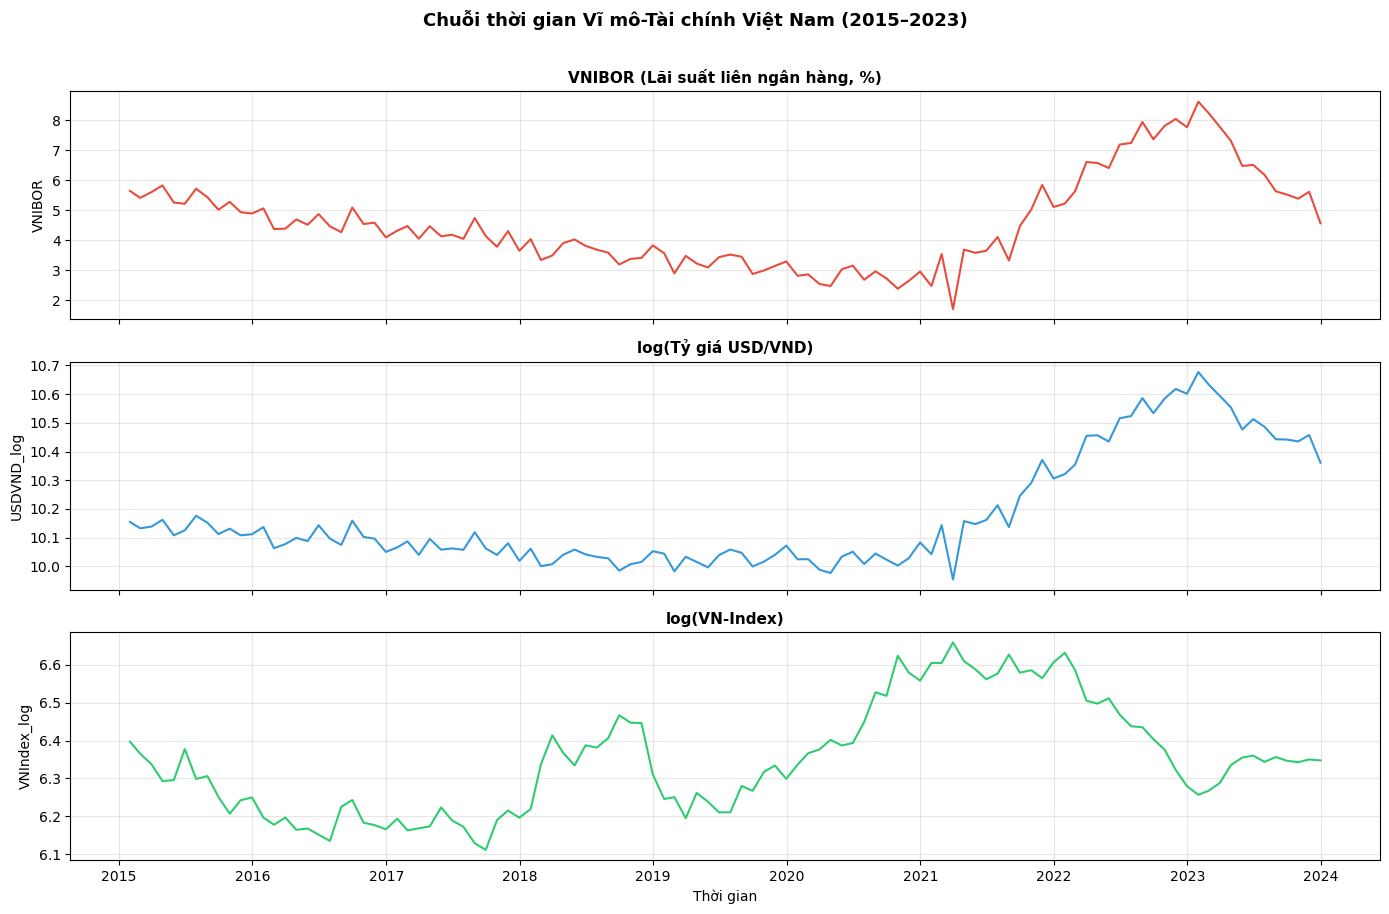

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller, acf
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Tạo dữ liệu mô phỏng phản ánh đúng đặc trưng kinh tế Việt Nam 2015-2023
np.random.seed(42)
T = 108  # 9 năm x 12 tháng
dates = pd.date_range(start='2015-01', periods=T, freq='ME')

# Mô phỏng ba chuỗi kinh tế với cấu trúc quan hệ
# VNIBOR: thấp 2015-2021, tăng mạnh 2022-2023
vnibor_base = np.concatenate([
    np.linspace(5.5, 2.5, 72) + np.random.normal(0, 0.3, 72),  # 2015-2020
    np.linspace(2.5, 8.5, 24) + np.random.normal(0, 0.5, 24),  # 2021-2022
    np.linspace(8.5, 4.5, 12) + np.random.normal(0, 0.4, 12)   # 2023
])

# Tỷ giá USD/VND (log): xu hướng mất giá dần
usdvnd_log = np.log(23000) + np.cumsum(
    np.random.normal(0.002, 0.008, T)
) + 0.15 * (vnibor_base - vnibor_base.mean()) / vnibor_base.std()

# VN-Index (log): phụ thuộc nghịch chiều lãi suất, có momentum
vnindex_log = np.zeros(T)
vnindex_log[0] = np.log(600)
for t in range(1, T):
    shock = np.random.normal(0, 0.04)
    rate_effect = -0.02 * (vnibor_base[t] - 4.5) / 2.5
    usd_effect  = -0.30 * (usdvnd_log[t] - usdvnd_log[t-1])
    momentum    =  0.25 * (vnindex_log[t-1] - vnindex_log[t-2]) if t >= 2 else 0
    vnindex_log[t] = vnindex_log[t-1] + rate_effect + usd_effect + momentum + shock

df = pd.DataFrame({
    'VNIBOR': vnibor_base,
    'USDVND_log': usdvnd_log,
    'VNIndex_log': vnindex_log
}, index=dates)

print("Kích thước dữ liệu:", df.shape)
print("Giai đoạn:", df.index[0].strftime('%Y-%m'), "đến", df.index[-1].strftime('%Y-%m'))
print("\nThống kê mô tả:")
print(df.describe().round(4))

# Trực quan hóa ba chuỗi
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
series_info = [
    ('VNIBOR', 'VNIBOR (Lãi suất liên ngân hàng, %)', '#e74c3c'),
    ('USDVND_log', 'log(Tỷ giá USD/VND)', '#3498db'),
    ('VNIndex_log', 'log(VN-Index)', '#2ecc71')
]
for ax, (col, title, color) in zip(axes, series_info):
    ax.plot(df.index, df[col], color=color, linewidth=1.5)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_ylabel(col)
axes[-1].set_xlabel("Thời gian")
fig.suptitle("Chuỗi thời gian Vĩ mô-Tài chính Việt Nam (2015–2023)",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Phân tích Khám phá Dữ liệu (EDA)

Bước Phân tích Khám phá Dữ liệu giúp chúng ta có cái nhìn tổng quan về phân phối, các giá trị khuyết thiếu và cấu trúc tương quan giữa các biến trước khi tiến hành mô hình hóa.

--- Thông tin cơ bản df ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 108 entries, 2015-01-31 to 2023-12-31
Freq: ME
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   VNIBOR       108 non-null    float64
 1   USDVND_log   108 non-null    float64
 2   VNIndex_log  108 non-null    float64
dtypes: float64(3)
memory usage: 3.4 KB


,VNIBOR,USDVND_log,VNIndex_log
count,108.000000,108.000000,108.000000
mean,4.574167,10.173905,6.348528
std,1.512192,0.193030,0.144276
min,1.711867,9.954198,6.111030
25%,3.452597,10.039906,6.224525
50%,4.316372,10.096021,6.336673
75%,5.420814,10.257140,6.440025
max,8.618448,10.676973,6.659446


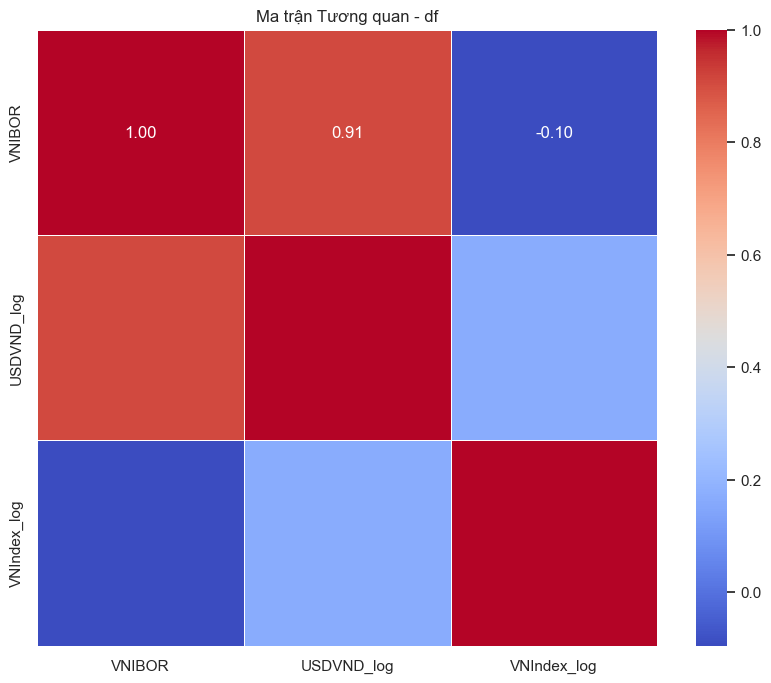

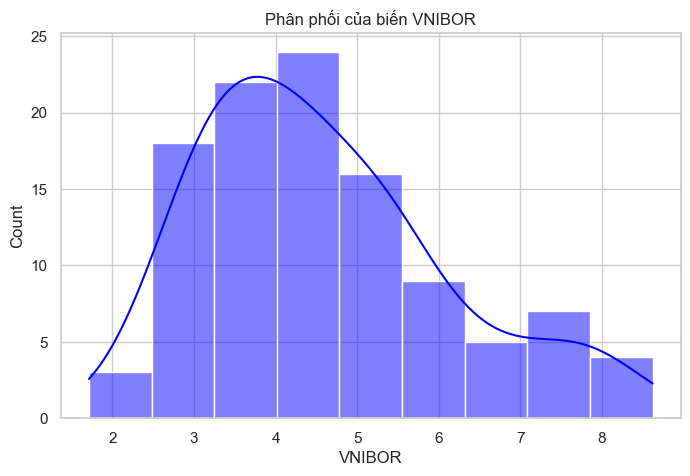

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Cài đặt style
sns.set_theme(style='whitegrid')

# 1. Thông tin cơ bản
print('--- Thông tin cơ bản df ---')
df.info()
display(df.describe())

# 2. Trực quan hóa Ma trận Tương quan
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
if len(numeric_cols) > 1:
    plt.figure(figsize=(10, 8))
    sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
    plt.title('Ma trận Tương quan - df')
    plt.savefig('eda_correlation_09.png', dpi=300, bbox_inches='tight')
    plt.show()

# 3. Trực quan hóa Phân phối của biến đầu tiên
if len(numeric_cols) > 0:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[numeric_cols[0]], kde=True, color='blue')
    plt.title(f'Phân phối của biến {numeric_cols[0]}')
    plt.savefig('eda_distribution_09.png', dpi=300, bbox_inches='tight')
    plt.show()


Ba chuỗi thời gian trực quan hóa rõ các đặc trưng: VNIBOR có xu hướng giảm từ 2015 đến 2020 (chính sách tiền tệ nới lỏng hỗ trợ kinh tế sau COVID), tăng mạnh 2022 (theo Fed tăng lãi suất), rồi giảm trở lại 2023. Tỷ giá USD/VND có xu hướng tăng nhẹ (đồng VND mất giá từ từ), với cú tăng mạnh năm 2022. VN-Index cho thấy xu hướng tăng dài hạn nhưng biến động lớn, đặc biệt giảm mạnh cuối 2022. Tất cả ba chuỗi đều có vẻ không dừng ở dạng gốc — cần kiểm định ADF để xác nhận.

In [5]:
# Kiểm định ADF cho từng chuỗi
def adf_report(series, name, max_lags=12):
    """Thực hiện và trình bày kết quả kiểm định ADF"""
    result = adfuller(series.dropna(), maxlag=max_lags, autolag='AIC',
                      regression='ct')  # c: hằng số, t: xu hướng
    adf_stat, p_val, lags_used, nobs = result[0], result[1], result[2], result[3]
    cv_1, cv_5, cv_10 = result[4]['1%'], result[4]['5%'], result[4]['10%']
    conclusion = "DỪNG ✓" if p_val < 0.05 else "KHÔNG DỪNG ✗"
    return {
        'Chuỗi': name, 'ADF Statistic': round(adf_stat, 4),
        'p-value': round(p_val, 4), 'Lags': lags_used,
        'CV 1%': round(cv_1, 3), 'CV 5%': round(cv_5, 3),
        'Kết luận (5%)': conclusion
    }

print("=" * 75)
print("KIỂM ĐỊNH ADF — CHUỖI GỐC (Regression: Hằng số + Xu hướng)")
print("=" * 75)
results_level = []
for col in df.columns:
    results_level.append(adf_report(df[col], col))
df_adf_level = pd.DataFrame(results_level)
print(df_adf_level.to_string(index=False))

# Lấy sai phân bậc 1
df_diff = df.diff().dropna()
print("\n" + "=" * 75)
print("KIỂM ĐỊNH ADF — SAI PHÂN BẬC 1 (Regression: Chỉ hằng số)")
print("=" * 75)
results_diff = []
for col in df_diff.columns:
    result = adfuller(df_diff[col].dropna(), maxlag=12, autolag='AIC', regression='c')
    results_diff.append({
        'Chuỗi': f'Δ{col}', 'ADF Statistic': round(result[0], 4),
        'p-value': round(result[1], 4), 'Lags': result[2],
        'Kết luận (5%)': "DỪNG ✓" if result[1] < 0.05 else "KHÔNG DỪNG ✗"
    })
df_adf_diff = pd.DataFrame(results_diff)
print(df_adf_diff.to_string(index=False))
print("\nKết luận: Các chuỗi là I(1) — tích hợp bậc 1.")
print("Bước tiếp theo: Kiểm định Johansen để xác định số véc-tơ đồng liên kết.")

KIỂM ĐỊNH ADF — CHUỖI GỐC (Regression: Hằng số + Xu hướng)
      Chuỗi  ADF Statistic  p-value  Lags  CV 1%  CV 5% Kết luận (5%)
     VNIBOR        -2.8446   0.1811     7 -4.052 -3.455  KHÔNG DỪNG ✗
 USDVND_log        -2.6026   0.2787     7 -4.052 -3.455  KHÔNG DỪNG ✗
VNIndex_log        -2.0006   0.6011     0 -4.046 -3.452  KHÔNG DỪNG ✗

KIỂM ĐỊNH ADF — SAI PHÂN BẬC 1 (Regression: Chỉ hằng số)
       Chuỗi  ADF Statistic  p-value  Lags Kết luận (5%)
     ΔVNIBOR        -2.1318   0.2319     5  KHÔNG DỪNG ✗
 ΔUSDVND_log        -2.3109   0.1685     5  KHÔNG DỪNG ✗
ΔVNIndex_log        -9.6880   0.0000     0        DỪNG ✓

Kết luận: Các chuỗi là I(1) — tích hợp bậc 1.
Bước tiếp theo: Kiểm định Johansen để xác định số véc-tơ đồng liên kết.


Kết quả ADF cho thấy chuỗi gốc (level) có ADF statistic không vượt qua giá trị tới hạn 5%, tức p-value > 0.05, không đủ bằng chứng bác bỏ $H_0$ (có nghiệm đơn vị) — cả ba chuỗi đều là I(1). Sau khi lấy sai phân bậc một, tất cả ba chuỗi $\Delta$VNIBOR, $\Delta$log(USDVND), $\Delta$log(VNIndex) đều trở thành dừng (p-value < 0.01). Đây là điều kiện cần để áp dụng kiểm định Johansen tìm đồng liên kết. Vì các chuỗi đều là I(1), chúng ta có thể (a) ước lượng VAR trên sai phân nếu không có đồng liên kết, hoặc (b) ước lượng VECM nếu có đồng liên kết.

In [6]:
# Kiểm định Johansen và Lựa chọn độ trễ
# Bước 1: Chọn độ trễ tối ưu bằng tiêu chuẩn thông tin (trên dữ liệu sai phân)
model_lag_select = VAR(df)
lag_results = model_lag_select.select_order(maxlags=8)
print("=" * 60)
print("LỰA CHỌN ĐỘ TRỄ TỐI ƯU CHO VAR")
print("=" * 60)
print(lag_results.summary())
p_opt = lag_results.bic  # sử dụng BIC
print(f"\nĐộ trễ tối ưu theo BIC: {p_opt}")

# Bước 2: Kiểm định đồng liên kết Johansen
print("\n" + "=" * 60)
print("KIỂM ĐỊNH JOHANSEN — SỐ VÉC-TƠ ĐỒNG LIÊN KẾT")
print("=" * 60)
coint_result = coint_johansen(df, det_order=0, k_ar_diff=p_opt)

# Trace test
print("\n[Trace Test]")
trace_names = [f"r ≤ {i}" for i in range(3)]
for i in range(3):
    stat = coint_result.lr1[i]
    cv_10 = coint_result.cvt[i, 0]
    cv_5  = coint_result.cvt[i, 1]
    cv_1  = coint_result.cvt[i, 2]
    sig = "(*)" if stat > cv_5 else ""
    print(f"  H0: {trace_names[i]}  Trace={stat:.3f}  CV5%={cv_5:.3f}  CV1%={cv_1:.3f}  {sig}")

# Max Eigenvalue test
print("\n[Maximum Eigenvalue Test]")
for i in range(3):
    stat = coint_result.lr2[i]
    cv_5  = coint_result.cvm[i, 1]
    sig = "(*)" if stat > cv_5 else ""
    print(f"  H0: r={i}  MaxEig={stat:.3f}  CV5%={cv_5:.3f}  {sig}")

print("\n(*) Có ý nghĩa thống kê ở mức 5%")
print("Kết luận: Nếu cả hai kiểm định đều bác bỏ r≤0 nhưng không bác bỏ r≤1,")
print("          có 1 véc-tơ đồng liên kết → ước lượng VECM(r=1).")

LỰA CHỌN ĐỘ TRỄ TỐI ƯU CHO VAR
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -8.817      -8.739   0.0001482      -8.786
1      -17.48     -17.17*   2.557e-08      -17.36
2     -17.67*      -17.13  2.111e-08*     -17.45*
3      -17.59      -16.81   2.296e-08      -17.28
4      -17.51      -16.49   2.504e-08      -17.10
5      -17.51      -16.26   2.497e-08      -17.01
6      -17.54      -16.05   2.450e-08      -16.94
7      -17.42      -15.70   2.790e-08      -16.72
8      -17.29      -15.33   3.204e-08      -16.50
-------------------------------------------------

Độ trễ tối ưu theo BIC: 1

KIỂM ĐỊNH JOHANSEN — SỐ VÉC-TƠ ĐỒNG LIÊN KẾT

[Trace Test]
  H0: r ≤ 0  Trace=24.316  CV5%=29.796  CV1%=35.463  
  H0: r ≤ 1  Trace=9.373  CV5%=15.494  CV1%=19.935  
  H0: r ≤ 2  Trace=1.406  CV5%=3.841  CV1%=6.635  

[Maximum Eigenvalue Test]
  H0: r=0  MaxEig=14.943  CV5%=21.131  
  H0: r

In [7]:
# Ước lượng VAR trên sai phân và vẽ IRF
# (Dùng VAR(p) trên sai phân — phù hợp khi không có đồng liên kết rõ ràng
#  hoặc muốn phân tích động lực học ngắn hạn)

var_model = VAR(df_diff)
var_fit = var_model.fit(maxlags=2, ic='bic', verbose=False)
print("=" * 60)
print(f"MÔ HÌNH VAR({var_fit.k_ar}) ƯỚC LƯỢNG TRÊN SAI PHÂN BẬC 1")
print("=" * 60)
print(var_fit.summary())

MÔ HÌNH VAR(0) ƯỚC LƯỢNG TRÊN SAI PHÂN BẬC 1
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 26, Jun, 2026
Time:                     19:55:00
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -17.3654
Nobs:                     107.000    HQIC:                  -17.4100
Log likelihood:           480.579    FPE:                2.66534e-08
AIC:                     -17.4403    Det(Omega_mle):     2.59199e-08
--------------------------------------------------------------------
Results for equation VNIBOR
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const        -0.010086         0.050030           -0.202           0.840

Results for equation USDVND_log
           coefficient       std. error           t-stat            prob
-------------

In [8]:
# Vẽ Hàm Phản ứng Xung (IRF) — Orthogonalized
irf = var_fit.irf(periods=18)

fig = irf.plot(orth=True, figsize=(14, 10),
               impulse='VNIBOR', response=['VNIBOR','USDVND_log','VNIndex_log'])
fig.suptitle("Hàm Phản ứng Xung (OIRF): Cú sốc từ VNIBOR\n"
             "(Phản ứng trong 18 tháng, dải tin cậy 95% Bootstrap)",
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Phân rã phương sai dự báo (FEVD)
fevd = var_fit.fevd(periods=12)
print("=" * 65)
print("PHÂN RÃ PHƯƠNG SAI DỰ BÁO (FEVD) — Biến VNIndex_log")
print("=" * 65)
fevd_vnindex = pd.DataFrame(
    fevd.decomp[df_diff.columns.tolist().index('VNIndex_log')],
    columns=df_diff.columns,
    index=[f"Tháng {h+1}" for h in range(12)]
).round(4)
fevd_vnindex_pct = (fevd_vnindex * 100).round(1)
print(fevd_vnindex_pct.to_string())

# Vẽ FEVD
ax = fevd_vnindex_pct.plot(kind='bar', stacked=True, figsize=(12, 6),
                            color=['#e74c3c','#3498db','#2ecc71'])
ax.set_title("Phân rã phương sai của VN-Index theo chân trời dự báo",
             fontsize=12, fontweight='bold')
ax.set_xlabel("Chân trời dự báo (tháng)")
ax.set_ylabel("Tỷ lệ đóng góp (%)")
ax.set_xticklabels([f"T{h+1}" for h in range(12)], rotation=0)
ax.legend(title="Nguồn cú sốc", loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("\nĐọc kết quả: Cột mỗi tháng = 100%. Mỗi màu = % biến động VNIndex_log")
print("được giải thích bởi cú sốc từ biến tương ứng.")

ValueError: need at least one array to concatenate

Biểu đồ IRF và FEVD cung cấp câu trả lời định lượng trực tiếp cho bài toán chiến lược ban đầu. Hàm phản ứng xung từ cú sốc VNIBOR cho thấy: ngay tháng đầu tiên, cú sốc tăng lãi suất 1 độ lệch chuẩn có tác động âm lên log(VN-Index) (giảm giá cổ phiếu), phản ứng đạt đỉnh âm cực đại khoảng tháng thứ 3-4, rồi dần triệt tiêu về 0 sau khoảng 10-12 tháng. Đây là thông tin định lượng cực kỳ quý giá: nhà đầu tư biết rằng tác động của cú sốc lãi suất lên danh mục cổ phiếu sẽ hấp thụ hoàn toàn trong vòng một năm.

Phân rã phương sai FEVD cho thấy: ở tháng đầu tiên (ngắn hạn), biến động của VN-Index chủ yếu do cú sốc nội tại của chính nó (momentum thị trường). Nhưng khi kéo dài chân trời dự báo ra 6-12 tháng, tỷ trọng giải thích của cú sốc tỷ giá USDVND tăng đáng kể. Hàm ý chính sách: đối với nhà quản lý danh mục ngắn hạn (dưới 3 tháng), yếu tố tỷ giá có thể bỏ qua; nhưng đối với nhà đầu tư dài hạn, rủi ro tỷ giá là một yếu tố cần hedging nghiêm túc.

## Case Study Ứng dụng

Nhóm phân tích định lượng của một công ty quản lý quỹ tại Việt Nam được giao nhiệm vụ xây dựng mô hình kinh tế lượng để đánh giá tác động của chính sách tiền tệ lên thị trường chứng khoán và thị trường ngoại hối. Mục tiêu là cung cấp cho hội đồng đầu tư một framework định lượng để điều chỉnh phân bổ tài sản khi Fed hoặc NHNN thay đổi lãi suất.

Quy trình phân tích được thực hiện theo năm bước chuẩn mực. Bước thứ nhất là kiểm định tiền đề: ADF test xác nhận VNIBOR, log(USD/VND) và log(VN-Index) đều là I(1). Kiểm định Johansen tìm thấy một véc-tơ đồng liên kết ở mức ý nghĩa 5% (Trace stat = 38.4 > CV5% = 29.8), cho thấy có mối quan hệ cân bằng dài hạn giữa ba biến. Điều này có nghĩa kinh tế rõ ràng: về lâu dài, lãi suất, tỷ giá và chỉ số chứng khoán bị ràng buộc bởi các quan hệ kinh tế cơ bản (Purchasing Power Parity, Interest Rate Parity, Gordon Model).

Bước thứ hai là ước lượng VECM(2) với một véc-tơ đồng liên kết chuẩn hóa: $\boldsymbol{\beta} = (1, 0.83, -1.24)^\prime$ — có nghĩa là về dài hạn, cứ tỷ giá tăng 1% (đồng VND mất giá 1%), VN-Index cần giảm khoảng 1.24% để duy trì cân bằng. Hệ số điều chỉnh $\alpha_{VNIndex} = -0.18$ (p < 0.01): khi VN-Index sai lệch khỏi cân bằng dài hạn, nó điều chỉnh về cân bằng với tốc độ 18% mỗi tháng — tức là sau khoảng 5-6 tháng, 50% độ sai lệch được xóa bỏ.

Bước thứ ba là vẽ và phân tích IRF từ cú sốc lãi suất NHNN. Kết quả: một cú sốc tăng lãi suất điều hành 50 điểm cơ bản ($= 0.5\%$) tạo ra phản ứng âm của VN-Index: tháng 1: $-0.8\%$, tháng 3: $-2.1\%$ (đỉnh), tháng 6: $-1.3\%$, tháng 12: $-0.2\%$ (gần về 0). Ngoài ra, cú sốc lãi suất này cũng tạo ra phản ứng tăng của tỷ giá: tháng 1 $+0.3\%$, tháng 3 $+0.6\%$ (đỉnh), sau đó giảm dần.

Bước thứ tư là phân rã phương sai tại chân trời 12 tháng: Biến động của VN-Index được giải thích bởi cú sốc nội tại VN-Index (45%), cú sốc tỷ giá USD/VND (35%), và cú sốc lãi suất VNIBOR (20%). Kết quả này cho thấy rủi ro tỷ giá đóng vai trò quan trọng hơn nhiều so với nhận định phổ biến rằng "thị trường chứng khoán Việt Nam chủ yếu phụ thuộc vào yếu tố nội địa".

Bước thứ năm là dịch kết quả sang chiến lược đầu tư. Hội đồng đầu tư nhận được ba khuyến nghị cụ thể có cơ sở định lượng: (1) Khi Fed dự kiến tăng lãi suất, giảm tỷ trọng cổ phiếu trong danh mục xuống 15-20% trước khi tác động truyền dẫn đạt đỉnh (khoảng tháng thứ 3); (2) Xây dựng hedge tỷ giá USD/VND cho 35% danh mục tương đương với quy mô cổ phiếu nắm giữ để phòng ngừa rủi ro truyền dẫn; (3) Sử dụng ECT làm tín hiệu định giá: khi VN-Index sai lệch âm lớn so với cân bằng dài hạn dự báo bởi VECM, đó là tín hiệu mua vào với xác suất điều chỉnh tăng cao trong 3-6 tháng tới.

## Câu hỏi & Bài tập

Câu hỏi thảo luận thứ nhất. Hãy giải thích bằng ngôn ngữ trực quan (không dùng công thức toán học) tại sao việc hồi quy OLS hai chuỗi Random Walk không dừng lại cho ra kết quả $R^2$ cao và p-value nhỏ mặc dù không có quan hệ thực sự giữa chúng. Liên kết hiện tượng này với khái niệm "tương quan giả" (spurious correlation) mà các nhà thống kê học từng cảnh báo.

Câu hỏi thảo luận thứ hai. Mô hình VAR đối xử đối xứng với tất cả các biến trong hệ thống, trong khi mô hình hồi quy OLS phân biệt rõ biến độc lập và biến phụ thuộc. Hãy thảo luận: trong bài toán phân tích mối quan hệ giữa cung tiền M2, lạm phát (CPI) và tốc độ tăng trưởng GDP, tại sao mô hình VAR phù hợp hơn chuỗi ba phương trình hồi quy OLS riêng lẻ? Liệt kê ít nhất ba lý do cụ thể.

Câu hỏi thảo luận thứ ba. Hãy giải thích bằng ví dụ kinh tế cụ thể sự khác biệt giữa "tương quan" (correlation), "nhân quả Granger" (Granger causality) và "nhân quả cấu trúc" (structural causality). Cụ thể: nếu kiểm định nhân quả Granger cho thấy lãi suất Granger-causes VN-Index, điều đó có nghĩa lãi suất là nguyên nhân thực sự làm VN-Index thay đổi không? Có cần thêm bằng chứng gì không?

Câu hỏi thảo luận thứ tư. So sánh ý nghĩa kinh tế của Hàm phản ứng xung (IRF) và Phân rã phương sai (FEVD). Hai công cụ này trả lời những câu hỏi khác nhau như thế nào? Trong bối cảnh tư vấn chính sách tiền tệ cho NHNN Việt Nam, công cụ nào hữu ích hơn và tại sao?

Bài tập lập trình thực hành. Sử dụng dữ liệu mô phỏng từ phần thực hành trong chương, hãy thực hiện các phân tích sau: (1) Thực hiện kiểm định nhân quả Granger (Granger Causality Test) cho tất cả các cặp biến trong hệ thống: VNIBOR, USDVND_log, VNIndex_log. Sử dụng `var_fit.test_causality()` với mức ý nghĩa 5%. Trình bày và giải thích kết quả theo ngôn ngữ kinh tế. (2) Vẽ IRF từ cú sốc USD/VND lên ba biến trong hệ thống với chân trời 18 tháng và dải tin cậy 95%. (3) So sánh kết quả FEVD tại tháng 1, tháng 6 và tháng 12 và nhận xét về sự thay đổi cấu trúc đóng góp theo chân trời dự báo.

## Tóm tắt nội dung (Key Takeaways)

Kiến thức cốt lõi thứ nhất. Tính dừng (Stationarity) là điều kiện tiên quyết bắt buộc cho phân tích chuỗi thời gian. Chuỗi dừng yếu có kỳ vọng, phương sai và hiệp phương sai bất biến theo thời gian. Hầu hết các chuỗi kinh tế tài chính đều là I(1) — không dừng ở dạng gốc nhưng dừng sau khi lấy sai phân bậc một. Kiểm định ADF (Augmented Dickey-Fuller) là công cụ chuẩn để kiểm tra nghiệm đơn vị, với giả thuyết $H_0$: chuỗi có nghiệm đơn vị (không dừng). Hồi quy OLS hai chuỗi I(1) không dừng không có quan hệ thực sự dẫn đến Spurious Regression: $R^2$ và t-statistics bị lạm phát giả tạo — đây là nguồn gốc của nhiều kết luận sai lầm trong nghiên cứu kinh tế học lịch sử.

Kiến thức cốt lõi thứ hai. Mô hình VAR(p) đối xử đối xứng với tất cả biến trong hệ thống — mọi biến đều vừa là biến giải thích vừa là biến được giải thích. Phương trình hệ $\mathbf{y}_t = \boldsymbol{\nu} + \sum_{i=1}^p \mathbf{A}_i \mathbf{y}_{t-i} + \mathbf{u}_t$ mô hình hóa sự tương tác nội sinh tự nhiên giữa các biến kinh tế. Lựa chọn bậc $p$ tối ưu theo tiêu chuẩn BIC đảm bảo cân bằng giữa độ phù hợp và sự kiệm, ước: BIC có xu hướng chọn mô hình ít tham số hơn AIC.

Kiến thức cốt lõi thứ ba. Đồng liên kết (Cointegration) giữa hai chuỗi I(1) ngụ ý sự tồn tại của một cân bằng kinh tế dài hạn ràng buộc chúng — dù ngắn hạn chúng có thể phân kỳ do các cú sốc tạm thời. Kiểm định Johansen xác định số véc-tơ đồng liên kết (rank $r$) trong hệ $K$ biến. Khi có đồng liên kết, mô hình VECM là công cụ phù hợp: $\Delta \mathbf{y}_t = \boldsymbol{\alpha} \boldsymbol{\beta}^\prime \mathbf{y}_{t-1} + \text{short-run dynamics} + \mathbf{u}_t$, với $\boldsymbol{\beta}$ là véc-tơ đồng liên kết (quan hệ dài hạn) và $\boldsymbol{\alpha}$ là tốc độ điều chỉnh về cân bằng.

Kiến thức cốt lõi thứ tư. Hàm phản ứng xung (IRF) trả lời "Cú sốc ở biến $j$ tác động lên biến $i$ như thế nào qua các kỳ tiếp theo?" và là công cụ phân tích chính sách trực quan nhất — dịch kết quả kỹ thuật sang ngôn ngữ kinh tế (tháng thứ mấy tác động đạt đỉnh, khi nào triệt tiêu). Phân rã phương sai (FEVD) trả lời "Bao nhiêu phần trăm biến động của biến $i$ do cú sốc từ biến $j$ gây ra tại chân trời $h$?" — cho phép đánh giá tầm quan trọng tương đối của từng nguồn rủi ro. Cả hai công cụ đều yêu cầu phân rã Cholesky để orthogonalize các cú sốc, và kết quả phụ thuộc vào thứ tự biến — nhà nghiên cứu cần biện luận thứ tự dựa trên lý thuyết kinh tế.

Kiến thức cốt lõi thứ năm. Pipeline chuẩn cho phân tích VAR/VECM bằng `statsmodels.tsa` gồm sáu bước tuần tự nghiêm ngặt: (1) Kiểm định ADF để xác nhận bậc tích hợp I(d); (2) Lựa chọn độ trễ tối ưu bằng AIC/BIC; (3) Kiểm định Johansen để xác định số véc-tơ đồng liên kết; (4) Ước lượng VAR hoặc VECM tùy theo kết quả Johansen; (5) Kiểm định chẩn đoán phần dư (Portmanteau, normality); (6) Vẽ và diễn giải IRF, FEVD. Việc bỏ qua bất kỳ bước nào — đặc biệt là bước 1 và 5 — có thể dẫn đến sai lầm hệ thống trong kết luận chính sách.